# Model 4 - ConvNeXt + Vision Mamba + Multi-Granularity Hypergraph
## Wound Image Segmentation

**Architecture:**
- Input: RGB wound image, multi-scale 4x4, 8x8, 16x16 patches
- Encoder: ConvNeXt stem + 3x (Residual CNN + Vision Mamba) stages
  - CNN captures local wound texture, Mamba captures global wound shape
- Deep Vision Mamba Context Block at bottleneck
- Multi-granularity nodes:
  - Fine (4x4 grid = 64 nodes): wound pixel-level detail
  - Mid  (8x8 grid = 32 nodes): wound region segments
  - Coarse (16x16 grid = 16 nodes): wound vs skin semantic
- Multi-granularity hypergraph: within-scale similarity + cross-scale spatial links
- Hierarchical HGNN: bottom-up (fine->coarse) + top-down (coarse refines boundaries)
- Wound anatomy symbolic fusion: continuity + boundary smoothness soft constraints
- Multi-scale decoder with deep supervision at 3 scales
- Loss: Boundary Dice + BCE with deep supervision (aux weights 0.4, 0.3, 0.2)
- Training: AdamW, warmup + cosine annealing, EMA=0.999, gradient clipping, 6-fold TTA
- Data: FUSC + Medetec, stratified 70/15/15

## 1. Imports and Configuration

In [1]:
import os
import math
import json
import random
import warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms
from torchvision.models import ConvNeXt_Base_Weights
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from sklearn.model_selection import StratifiedKFold
from scipy.ndimage import binary_erosion

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DATA_BASE     = "/kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data"
IMG_SIZE      = 512
FINE_PATCH    = 4
MID_PATCH     = 8
COARSE_PATCH  = 16
FINE_NODES    = 64
MID_NODES     = 16
COARSE_NODES  = 4
TOTAL_NODES   = FINE_NODES + MID_NODES + COARSE_NODES
NODE_DIM      = 256
NUM_EPOCHS    = 50
BATCH_SIZE    = 4
LR            = 1e-4
WARMUP_EPOCHS = 5
EMA_DECAY     = 0.999
PATIENCE      = 10
DROPOUT_RATE  = 0.1
N_FINE   = FINE_NODES 
N_MID    = MID_NODES   
N_COARSE = COARSE_NODES 
N_TOTAL  = TOTAL_NODES 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device      : {DEVICE}")
print(f"PyTorch     : {torch.__version__}")
print(f"IMG_SIZE    : {IMG_SIZE}")
print(f"Node counts : fine={FINE_NODES}  mid={MID_NODES}  coarse={COARSE_NODES}  total={TOTAL_NODES}")


Device      : cuda
PyTorch     : 2.10.0+cu128
IMG_SIZE    : 512
Node counts : fine=64  mid=16  coarse=4  total=84


## 2. Dataset Discovery

In [2]:
def _find_dir(base, keyword):
    if not os.path.isdir(base): return None
    for name in sorted(os.listdir(base)):
        if keyword.lower() in name.lower() and os.path.isdir(os.path.join(base, name)):
            return os.path.join(base, name)
    return None

_FUSC = _find_dir(DATA_BASE, "Foot Ulcer")
_MED  = _find_dir(DATA_BASE, "Medetec")

print(f"DATA_BASE : {DATA_BASE}")
print(f"FUSC root : {_FUSC}  ({'found' if _FUSC else 'NOT FOUND'})")
print(f"MED  root : {_MED}   ({'found' if _MED  else 'NOT FOUND'})")
print("\nAll folders inside DATA_BASE:")
for name in sorted(os.listdir(DATA_BASE)):
    print(f"  {name}")

assert _FUSC is not None, f"Cannot find Foot Ulcer dataset under {DATA_BASE}"
assert _MED  is not None, f"Cannot find Medetec dataset under {DATA_BASE}"

def _lbl(p): return p if os.path.isdir(p) else None

FOLDER_PAIRS = [
    (os.path.join(_FUSC, "train",      "images"), _lbl(os.path.join(_FUSC, "train",      "labels"))),
    (os.path.join(_FUSC, "validation", "images"), _lbl(os.path.join(_FUSC, "validation", "labels"))),
    (os.path.join(_FUSC, "test",       "images"), _lbl(os.path.join(_FUSC, "test",       "labels"))),
    (os.path.join(_MED,  "train",      "images"), _lbl(os.path.join(_MED,  "train",      "labels"))),
    (os.path.join(_MED,  "test",       "images"), _lbl(os.path.join(_MED,  "test",       "labels"))),
]

print("\nFolder pair check:")
for img_d, lbl_d in FOLDER_PAIRS:
    ok = os.path.isdir(img_d)
    n  = len([f for f in os.listdir(img_d)
               if f.lower().endswith((".jpg",".jpeg",".png",".bmp"))]) if ok else 0
    ls = f"labels: {len(os.listdir(lbl_d))} files" if lbl_d else "labels: none"
    print(f"  [{'OK' if ok else 'MISSING'}] {img_d}  |  images={n}  |  {ls}")


DATA_BASE : /kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data
FUSC root : /kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data/Foot Ulcer Segmentation Challenge  (found)
MED  root : /kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data/Medetec_foot_ulcer_224   (found)

All folders inside DATA_BASE:
  Foot Ulcer Segmentation Challenge
  Medetec_foot_ulcer_224
  wound_dataset

Folder pair check:
  [OK] /kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data/Foot Ulcer Segmentation Challenge/train/images  |  images=810  |  labels: 810 files
  [OK] /kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data/Foot Ulcer Segmentation Challenge/validation/images  |  images=200  |  labels: 200 files
  [OK] /kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data/Foot Ulcer Segmentation Challenge/test/images  |  images=200  |  labels: none
  [OK] /kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data/Medetec_foot_ulcer_224/train/images  |  images=152  |  labels

## 3. Dataset Classes

In [3]:
class TrainAugmentation:
    def __init__(self, img_size=IMG_SIZE):
        self.img_size = img_size

    def __call__(self, img_np, mask_np):
        if random.random() < 0.5:
            img_np = np.fliplr(img_np).copy(); mask_np = np.fliplr(mask_np).copy()
        if random.random() < 0.5:
            img_np = np.flipud(img_np).copy(); mask_np = np.flipud(mask_np).copy()
        k = random.randint(0, 3)
        if k:
            img_np = np.rot90(img_np, k).copy(); mask_np = np.rot90(mask_np, k).copy()
        if random.random() < 0.3:
            h, w = img_np.shape[:2]; gs = 16
            dx = cv2.GaussianBlur((np.random.rand(h//gs+1,w//gs+1)*2-1).astype(np.float32),(0,0),3)
            dy = cv2.GaussianBlur((np.random.rand(h//gs+1,w//gs+1)*2-1).astype(np.float32),(0,0),3)
            dx = cv2.resize(dx,(w,h))*15; dy = cv2.resize(dy,(w,h))*15
            x, y = np.meshgrid(np.arange(w), np.arange(h))
            mx = np.clip(x+dx,0,w-1).astype(np.float32)
            my = np.clip(y+dy,0,h-1).astype(np.float32)
            img_np  = cv2.remap(img_np, mx, my, cv2.INTER_LINEAR)
            mask_np = cv2.remap(mask_np,mx, my, cv2.INTER_NEAREST)
        if random.random() < 0.5:
            p = Image.fromarray(img_np)
            p = transforms.functional.adjust_brightness(p, random.uniform(0.75,1.25))
            p = transforms.functional.adjust_contrast(p,   random.uniform(0.75,1.25))
            p = transforms.functional.adjust_saturation(p, random.uniform(0.75,1.25))
            img_np = np.array(p)
        return img_np, mask_np


class _SingleFolderDataset(Dataset):
    EXTS = (".jpg",".jpeg",".png",".bmp")

    def __init__(self, img_dir, lbl_dir, img_size=IMG_SIZE, augment=False):
        self.img_dir  = img_dir
        self.lbl_dir  = lbl_dir if (lbl_dir and os.path.isdir(lbl_dir)) else None
        self.img_size = img_size
        self.aug_fn   = TrainAugmentation(img_size) if augment else None
        self.ids      = sorted([f for f in os.listdir(img_dir)
                                if f.lower().endswith(self.EXTS)])
        self.img_tf   = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

    def __len__(self): return len(self.ids)

    def _fg_crop(self, img_np, mask_np):
        ys, xs = np.where(mask_np > 0)
        if not len(ys): return img_np, mask_np
        pad = 10; h, w = mask_np.shape
        return (img_np [max(0,ys.min()-pad):min(h,ys.max()+pad),
                        max(0,xs.min()-pad):min(w,xs.max()+pad)],
                mask_np[max(0,ys.min()-pad):min(h,ys.max()+pad),
                        max(0,xs.min()-pad):min(w,xs.max()+pad)])

    def __getitem__(self, idx):
        fname = self.ids[idx]; stem = os.path.splitext(fname)[0]
        img_np = np.array(Image.open(os.path.join(self.img_dir,fname)).convert("RGB"))
        mask_np = np.zeros(img_np.shape[:2], dtype=np.uint8); has_lbl = False
        if self.lbl_dir:
            for ext in (".png",".jpg",".jpeg",".bmp"):
                p = os.path.join(self.lbl_dir, stem+ext)
                if os.path.exists(p):
                    mask_np = (np.array(Image.open(p).convert("L"))>127).astype(np.uint8)
                    has_lbl = True; break
        if has_lbl:  img_np, mask_np = self._fg_crop(img_np, mask_np)
        if self.aug_fn and has_lbl: img_np, mask_np = self.aug_fn(img_np, mask_np)
        ip = Image.fromarray(img_np).resize((self.img_size,self.img_size), Image.BILINEAR)
        mp = Image.fromarray(mask_np*255).resize((self.img_size,self.img_size), Image.NEAREST)
        return self.img_tf(ip), torch.from_numpy(np.array(mp)>127).float().unsqueeze(0)


class MultiDatasetWoundDataset(Dataset):
    def __init__(self, folder_pairs=FOLDER_PAIRS, img_size=IMG_SIZE, augment=False):
        self._sub=[]; self._off=[]; total=0
        for img_d, lbl_d in folder_pairs:
            if img_d and os.path.isdir(img_d):
                ds = _SingleFolderDataset(img_d, lbl_d, img_size, augment)
                if len(ds):
                    self._sub.append(ds); self._off.append(total); total+=len(ds)
        self._total = total
        print(f"Loaded {len(self._sub)} sub-datasets, {self._total} total images")
        for ds in self._sub:
            tag = "labels:yes" if ds.lbl_dir else "labels:none"
            print(f"  {os.path.basename(os.path.dirname(ds.img_dir))}/images ({len(ds)}, {tag})")

    def __len__(self): return self._total

    def _resolve(self, idx):
        s = 0
        for i in range(len(self._off)-1,-1,-1):
            if idx >= self._off[i]: s=i; break
        return self._sub[s], idx-self._off[s]

    def __getitem__(self, idx):
        ds, local = self._resolve(idx); return ds[local]

    def get_label_flags(self):
        f = np.zeros(self._total, dtype=int)
        for sub, off in zip(self._sub, self._off):
            if sub.lbl_dir: f[off:off+len(sub)] = 1
        return f

    def get_splits(self, train_r=0.70, val_r=0.15, seed=SEED):
        print("Computing stratified split ...")
        flags = self.get_label_flags(); idx = np.arange(len(flags))
        skf  = StratifiedKFold(n_splits=max(2,round(1/(1-train_r))),shuffle=True,random_state=seed)
        tr, tmp = next(skf.split(idx, flags))
        skf2 = StratifiedKFold(n_splits=max(2,round(1/(val_r/(1-train_r)))),shuffle=True,random_state=seed)
        vr, ter = next(skf2.split(tmp, flags[tmp]))
        val_idx=tmp[vr]; test_idx=tmp[ter]
        print(f"Split -> train:{len(tr)}  val:{len(val_idx)}  test:{len(test_idx)}")
        return Subset(self,tr.tolist()), Subset(self,val_idx.tolist()), Subset(self,test_idx.tolist())


print("Scanning datasets ...")
full_aug   = MultiDatasetWoundDataset(augment=True)
full_noaug = MultiDatasetWoundDataset(augment=False)
train_sub, val_sub, test_sub = full_noaug.get_splits()
train_ds = Subset(full_aug,   train_sub.indices)
val_ds   = Subset(full_noaug, val_sub.indices)
test_ds  = Subset(full_noaug, test_sub.indices)
train_loader = DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True,
                          num_workers=2,pin_memory=True,drop_last=True)
val_loader   = DataLoader(val_ds,  batch_size=BATCH_SIZE,shuffle=False,
                          num_workers=2,pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=1,shuffle=False)
print(f"Train:{len(train_loader)} batches  Val:{len(val_loader)} batches  Test:{len(test_ds)} samples")


Scanning datasets ...
Loaded 5 sub-datasets, 1370 total images
  train/images (810, labels:yes)
  validation/images (200, labels:yes)
  test/images (200, labels:none)
  train/images (152, labels:yes)
  test/images (8, labels:yes)
Loaded 5 sub-datasets, 1370 total images
  train/images (810, labels:yes)
  validation/images (200, labels:yes)
  test/images (200, labels:none)
  train/images (152, labels:yes)
  test/images (8, labels:yes)
Computing stratified split ...
Split -> train:913  val:228  test:229
Train:228 batches  Val:57 batches  Test:229 samples


## 4. Data Exploration

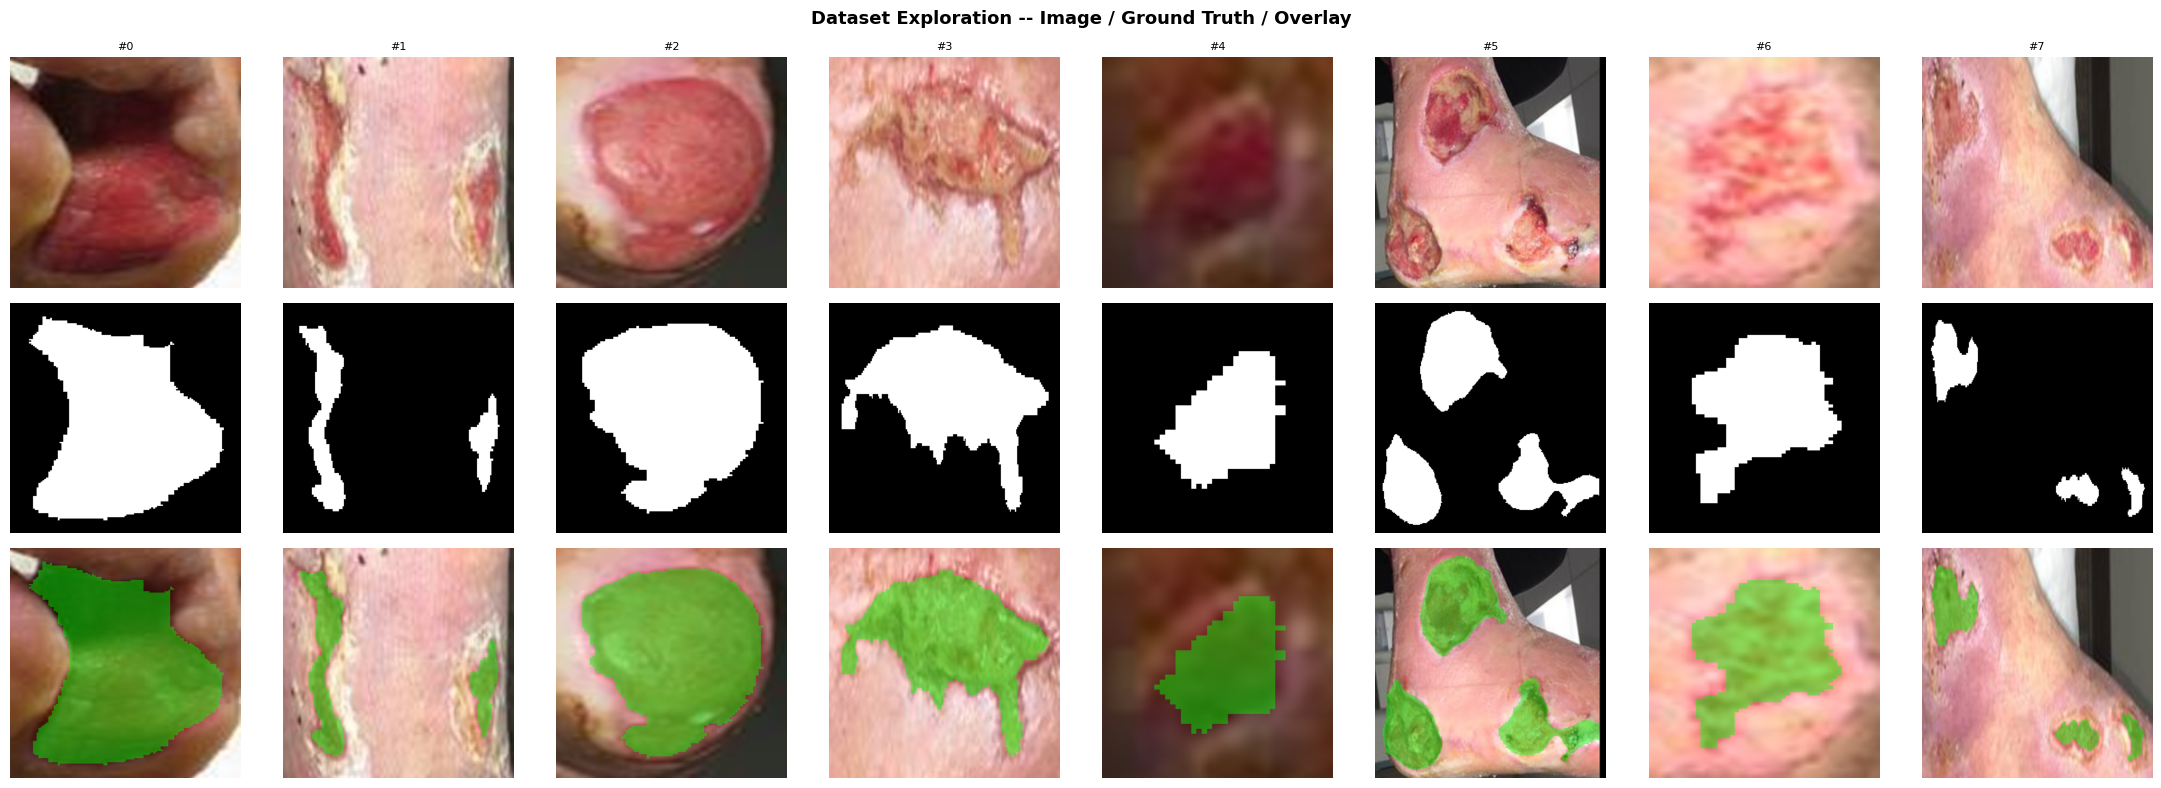

Saved data_exploration_m3.png


In [4]:
def denorm(t):
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    return (t.cpu()*std+mean).clamp(0,1).permute(1,2,0).numpy()

def overlay_mask(img_np, mask_np, alpha=0.45):
    out = img_np.copy()
    out[mask_np>0] = out[mask_np>0]*(1-alpha) + np.array([0,1,0])*alpha
    return out.clip(0,1)

sample_idx = []
for i in range(len(full_noaug)):
    _, m = full_noaug[i]
    if m.sum() > 0: sample_idx.append(i)
    if len(sample_idx) == 8: break

fig, axes = plt.subplots(3, 8, figsize=(22,8))
fig.suptitle("Dataset Exploration -- Image / Ground Truth / Overlay",
             fontsize=13, fontweight="bold")
for col, idx in enumerate(sample_idx):
    img_t, mask_t = full_noaug[idx]
    img_np = denorm(img_t); mask_np = mask_t[0].numpy()
    axes[0,col].imshow(img_np);          axes[0,col].set_title(f"#{idx}",fontsize=8)
    axes[1,col].imshow(mask_np,cmap="gray")
    axes[2,col].imshow(overlay_mask(img_np, mask_np))
    for r in range(3): axes[r,col].axis("off")
axes[0,0].set_ylabel("Image",        fontsize=9, labelpad=6)
axes[1,0].set_ylabel("Ground Truth", fontsize=9, labelpad=6)
axes[2,0].set_ylabel("Overlay",      fontsize=9, labelpad=6)
plt.tight_layout()
plt.savefig("data_exploration_m3.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved data_exploration_m3.png")


## 5. Model Architecture

In [5]:
# ================================================================
# 5A. Mamba SSM Block
# ================================================================
class SSMBlock(nn.Module):
    def __init__(self, dim, d_state=16, d_conv=4, expand=2):
        super().__init__()
        d_inner = int(expand*dim)
        self.d_inner = d_inner; self.d_state = d_state
        self.norm     = nn.LayerNorm(dim)
        self.in_proj  = nn.Linear(dim, d_inner*2, bias=False)
        self.conv1d   = nn.Conv1d(d_inner, d_inner, kernel_size=d_conv,
                                  padding=d_conv-1, groups=d_inner, bias=True)
        self.act      = nn.SiLU()
        self.x_proj   = nn.Linear(d_inner, d_state*2+1, bias=False)
        self.dt_proj  = nn.Linear(1, d_inner, bias=True)
        self.out_proj = nn.Linear(d_inner, dim, bias=False)
        self.dropout  = nn.Dropout(DROPOUT_RATE)
        a_log = (torch.log(torch.arange(1,d_state+1).float())
                 .unsqueeze(0).expand(d_inner,-1).contiguous())
        self.A_log = nn.Parameter(a_log)
        self.D     = nn.Parameter(torch.ones(d_inner))
        nn.init.normal_(self.dt_proj.weight, std=0.01)
        nn.init.zeros_(self.dt_proj.bias)

    def forward(self, x):
        res = x; x = self.norm(x); B,L,C = x.shape
        x_in, z = self.in_proj(x).chunk(2, dim=-1)
        x_in = self.conv1d(x_in.transpose(1,2))[...,:L].transpose(1,2)
        x_in = self.act(x_in)
        dt_raw,_,_ = torch.split(self.x_proj(x_in),[1,self.d_state,self.d_state],dim=-1)
        dt = F.softplus(self.dt_proj(dt_raw.clamp(-4,4)))
        y  = x_in*self.D + (x_in*torch.sigmoid(dt)).cumsum(dim=1)/max(L,1)
        return self.dropout(self.out_proj(y*torch.sigmoid(z))) + res


# ================================================================
# 5B. ConvNeXt stem + 3x (Residual CNN + Vision Mamba) Encoder
# ================================================================
class ResidualCNNMambaStage(nn.Module):
    def __init__(self, in_ch, out_ch, stride=2):
        super().__init__()
        self.res       = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch))
        self.skip_proj = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.act       = nn.GELU()
        self.down      = nn.Conv2d(out_ch, out_ch, kernel_size=stride, stride=stride)
        self.norm      = nn.GroupNorm(min(32,out_ch), out_ch)
        self.mamba     = SSMBlock(out_ch)
        self.proj      = nn.Conv2d(out_ch, out_ch, 1)

    def forward(self, x):
        skip = self.skip_proj(x)
        x    = self.act(self.res(x) + skip); skip2 = x  # skip2 = out_ch channels
        x    = self.down(x)
        B,C,H,W = x.shape
        x_n  = self.norm(x)
        x_m  = self.mamba(x_n.flatten(2).transpose(1,2)).transpose(1,2).reshape(B,C,H,W)
        x    = self.proj(x_m) + x
        return skip2, x


class ConvNeXtStem(nn.Module):
    def __init__(self, in_ch=3, out_ch=96):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=4, stride=4),
            nn.GroupNorm(1, out_ch))
    def forward(self, x): return self.stem(x)


class Model4Encoder(nn.Module):
    def __init__(self, base_ch=96):
        super().__init__()
        self.stem   = ConvNeXtStem(3, base_ch)
        self.stage1 = ResidualCNNMambaStage(base_ch,   base_ch*2, stride=2)  # skip→192ch
        self.stage2 = ResidualCNNMambaStage(base_ch*2, base_ch*4, stride=2)  # skip→384ch
        self.stage3 = ResidualCNNMambaStage(base_ch*4, base_ch*8, stride=2)  # skip→768ch
        self.deep_norm  = nn.GroupNorm(32, base_ch*8)
        self.deep_proj  = nn.Conv2d(base_ch*8, base_ch*8, 1)
        self.deep_mamba = SSMBlock(base_ch*8)
        self.base_ch    = base_ch

    def forward(self, x):
        f0       = self.stem(x)
        s1, f1   = self.stage1(f0)   # s1=192ch, f1=192ch
        s2, f2   = self.stage2(f1)   # s2=384ch, f2=384ch
        s3, f3   = self.stage3(f2)   # s3=768ch, f3=768ch
        B,C,H,W  = f3.shape
        f3_n     = self.deep_norm(f3)
        f3_m     = self.deep_mamba(f3_n.flatten(2).transpose(1,2)).transpose(1,2).reshape(B,C,H,W)
        f3       = self.deep_proj(f3_m) + f3
        return f0, s1, s2, s3, f3


# ================================================================
# 5C. Multi-Granularity Node Extractors
# ================================================================
class GranularityNodeExtractor(nn.Module):
    def __init__(self, in_ch, node_dim=NODE_DIM, grid_size=8):
        super().__init__()
        self.grid = grid_size; self.n = grid_size*grid_size
        self.pool = nn.AdaptiveAvgPool2d(grid_size)
        self.proj = nn.Linear(in_ch, node_dim)
        self.norm = nn.LayerNorm(node_dim)
        self.pos  = nn.Embedding(self.n, node_dim)

    def forward(self, feat):
        p = self.pool(feat).flatten(2).transpose(1,2)
        n = self.proj(p)
        n = n + self.pos(torch.arange(self.n, device=feat.device)).unsqueeze(0)
        return self.norm(n)


# ================================================================
# 5D. Multi-Granularity Hypergraph Builder
# ================================================================
def build_multigranularity_hypergraph(fine_n, mid_n, coarse_n,
                                      n_fine=N_FINE, n_mid=N_MID, n_coarse=N_COARSE,
                                      sim_thresh=0.6):
    N   = n_fine + n_mid + n_coarse
    adj = torch.zeros(N, N)

    def sim_adj(nodes, thresh=sim_thresh):
        nf  = F.normalize(nodes.detach().mean(0), dim=-1)
        sim = (nf @ nf.T > thresh).float()
        return (sim + torch.eye(sim.shape[0], device=sim.device)).clamp(max=1.)

    adj[:n_fine, :n_fine]                         = sim_adj(fine_n)
    adj[n_fine:n_fine+n_mid, n_fine:n_fine+n_mid] = sim_adj(mid_n)
    adj[n_fine+n_mid:, n_fine+n_mid:]             = sim_adj(coarse_n)

    fine_g   = int(n_fine  ** 0.5)
    mid_g    = math.ceil(n_mid   ** 0.5)
    coarse_g = math.ceil(n_coarse ** 0.5)

    if fine_g > 0 and mid_g > 0:
        ratio = max(fine_g // max(mid_g,1), 1)
        for fi in range(n_fine):
            fy,fx = fi//fine_g, fi%fine_g
            my = min(fy//ratio, mid_g-1); mx = min(fx//ratio, mid_g-1)
            mi = my*mid_g + mx
            if mi < n_mid:
                adj[fi, n_fine+mi] = 1.; adj[n_fine+mi, fi] = 1.

    if mid_g > 0 and coarse_g > 0:
        ratio2 = max(mid_g // max(coarse_g,1), 1)
        for mi in range(n_mid):
            my,mx = mi//mid_g, mi%mid_g
            cy = min(my//ratio2, coarse_g-1); cx = min(mx//ratio2, coarse_g-1)
            ci = cy*coarse_g + cx
            if ci < n_coarse:
                adj[n_fine+mi, n_fine+n_mid+ci] = 1.
                adj[n_fine+n_mid+ci, n_fine+mi] = 1.

    return (adj + torch.eye(N)).clamp(max=1.)


# ================================================================
# 5E. Hierarchical HGNN (bottom-up + top-down)
# ================================================================
class HGNNLayer(nn.Module):
    def __init__(self, node_dim=NODE_DIM, dropout=DROPOUT_RATE):
        super().__init__()
        self.W     = nn.Linear(node_dim, node_dim, bias=False)
        self.norm  = nn.LayerNorm(node_dim)
        self.ffn   = nn.Sequential(
            nn.Linear(node_dim,node_dim*2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(node_dim*2, node_dim))
        self.norm2 = nn.LayerNorm(node_dim)
        self.drop  = nn.Dropout(dropout)

    def forward(self, X, adj):
        Dv  = adj.sum(-1).clamp(min=1.)
        agg = (adj @ self.W(X).mean(0)) / Dv.unsqueeze(-1)
        agg = agg.unsqueeze(0).expand_as(X)
        X   = self.norm(X  + self.drop(agg))
        return self.norm2(X + self.drop(self.ffn(X)))


class HierarchicalHGNN(nn.Module):
    def __init__(self, node_dim=NODE_DIM, num_layers=3):
        super().__init__()
        self.bu_layers = nn.ModuleList([HGNNLayer(node_dim) for _ in range(num_layers)])
        self.td_layers = nn.ModuleList([HGNNLayer(node_dim) for _ in range(num_layers)])
        self.out_norm  = nn.LayerNorm(node_dim)

    def forward(self, nodes, adj):
        for layer in self.bu_layers: nodes = layer(nodes, adj)
        adj_t = adj.T.contiguous()
        for layer in self.td_layers: nodes = layer(nodes, adj_t)
        return self.out_norm(nodes)


# ================================================================
# 5F. Wound Anatomy Symbolic Fusion
# ================================================================
class WoundAnatomySymbolicFusion(nn.Module):
    def __init__(self, node_dim=NODE_DIM, n_fine=N_FINE, n_mid=N_MID, n_coarse=N_COARSE):
        super().__init__()
        self.n_fine=n_fine; self.n_mid=n_mid; self.n_coarse=n_coarse
        self.gate_f2m = nn.Sequential(nn.Linear(node_dim*2, node_dim), nn.Sigmoid())
        self.gate_m2c = nn.Sequential(nn.Linear(node_dim*2, node_dim), nn.Sigmoid())
        self.gate_c2m = nn.Sequential(nn.Linear(node_dim*2, node_dim), nn.Sigmoid())
        self.gate_m2f = nn.Sequential(nn.Linear(node_dim*2, node_dim), nn.Sigmoid())
        self.smooth_f = nn.Linear(node_dim, node_dim)
        self.smooth_c = nn.Linear(node_dim, node_dim)
        self.norm     = nn.LayerNorm(node_dim)

    def forward(self, nodes):
        fine_n   = nodes[:, :self.n_fine, :]
        mid_n    = nodes[:, self.n_fine:self.n_fine+self.n_mid, :]
        coarse_n = nodes[:, self.n_fine+self.n_mid:, :]
        mm = mid_n.mean(1,keepdim=True)
        gfm = self.gate_f2m(torch.cat([fine_n,   mm.expand_as(fine_n)],  -1))
        fine_n   = fine_n   + gfm * (mm.expand_as(fine_n) - fine_n)
        gmc = self.gate_m2c(torch.cat([coarse_n, mm.expand_as(coarse_n)],-1))
        coarse_n = coarse_n + gmc * (mm.expand_as(coarse_n) - coarse_n)
        cm = coarse_n.mean(1,keepdim=True)
        gcm = self.gate_c2m(torch.cat([mid_n,    cm.expand_as(mid_n)],   -1))
        mid_n    = mid_n    + gcm * (cm.expand_as(mid_n) - mid_n)
        mm2 = mid_n.mean(1,keepdim=True)
        gmf = self.gate_m2f(torch.cat([fine_n,   mm2.expand_as(fine_n)], -1))
        fine_n   = fine_n   + gmf * (mm2.expand_as(fine_n) - fine_n)
        fine_n   = self.smooth_f(fine_n)
        coarse_n = self.smooth_c(coarse_n)
        return self.norm(torch.cat([fine_n, mid_n, coarse_n], dim=1))


# ================================================================
# 5G. Multi-Scale Decoder with Deep Supervision
# ================================================================
class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout=DROPOUT_RATE):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.cv = nn.Sequential(
            nn.Conv2d(out_ch+skip_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.GELU(), nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.GELU())
    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None: x = torch.cat([x,skip],1)
        return self.cv(x)


class MultiScaleDecoder(nn.Module):
    def __init__(self, base_ch=96, node_dim=NODE_DIM):
        super().__init__()
        # Encoder skip channel sizes:
        #   s3 = base_ch*8 = 768  (stage3 skip, before downsample)
        #   s2 = base_ch*4 = 384  (stage2 skip)
        #   s1 = base_ch*2 = 192  (stage1 skip)
        self.fine_proj   = nn.Linear(node_dim, base_ch*8)
        self.mid_proj    = nn.Linear(node_dim, base_ch*8)
        self.coarse_proj = nn.Linear(node_dim, base_ch*8)
        self.dec3 = DecoderBlock(base_ch*8, base_ch*8, base_ch*4)  # 768→384 up, cat 768 skip → conv 384
        self.dec2 = DecoderBlock(base_ch*4, base_ch*4, base_ch*2)  # 384→192 up, cat 384 skip → conv 192
        self.dec1 = DecoderBlock(base_ch*2, base_ch*2, base_ch)    # 192→96  up, cat 192 skip → conv 96
        self.dec0 = DecoderBlock(base_ch,   0,          base_ch//2) # 96→48  up, no skip
        self.head = nn.Conv2d(base_ch//2, 1, 1)
        self.aux3 = nn.Conv2d(base_ch*4, 1, 1)
        self.aux2 = nn.Conv2d(base_ch*2, 1, 1)
        self.aux1 = nn.Conv2d(base_ch,   1, 1)

    def forward(self, f3, s3, s2, s1, nodes, img_size, n_fine=N_FINE, n_mid=N_MID):
        B,C,H,W  = f3.shape
        fc = self.fine_proj(nodes[:,:n_fine,:]).mean(1)[:,:,None,None].expand(B,-1,H,W)
        mc = self.mid_proj(nodes[:,n_fine:n_fine+n_mid,:]).mean(1)[:,:,None,None].expand(B,-1,H,W)
        cc = self.coarse_proj(nodes[:,n_fine+n_mid:,:]).mean(1)[:,:,None,None].expand(B,-1,H,W)
        x  = f3 + fc*0.3 + mc*0.4 + cc*0.3
        x  = self.dec3(x, s3); aux3 = self.aux3(x)
        x  = self.dec2(x, s2); aux2 = self.aux2(x)
        x  = self.dec1(x, s1); aux1 = self.aux1(x)
        x  = self.dec0(x)
        logits = F.interpolate(self.head(x), img_size, mode="bilinear", align_corners=False)
        if self.training:
            aux3 = F.interpolate(aux3, img_size, mode="bilinear", align_corners=False)
            aux2 = F.interpolate(aux2, img_size, mode="bilinear", align_corners=False)
            aux1 = F.interpolate(aux1, img_size, mode="bilinear", align_corners=False)
            return logits, aux3, aux2, aux1
        return logits


# ================================================================
# 5H. Full Model
# ================================================================
class WoundSegModel4(nn.Module):
    def __init__(self, base_ch=96, node_dim=NODE_DIM,
                 n_fine=N_FINE, n_mid=N_MID, n_coarse=N_COARSE):
        super().__init__()
        self.n_fine=n_fine; self.n_mid=n_mid; self.n_coarse=n_coarse
        self.encoder  = Model4Encoder(base_ch)
        fine_g   = int(n_fine  ** 0.5)
        mid_g    = math.ceil(n_mid   ** 0.5)
        coarse_g = math.ceil(n_coarse ** 0.5)
        self.fine_extractor   = GranularityNodeExtractor(base_ch,   node_dim, fine_g)
        self.mid_extractor    = GranularityNodeExtractor(base_ch*2, node_dim, mid_g)
        self.coarse_extractor = GranularityNodeExtractor(base_ch*4, node_dim, coarse_g)
        self.hgnn       = HierarchicalHGNN(node_dim, num_layers=3)
        self.sym_fusion = WoundAnatomySymbolicFusion(node_dim, n_fine, n_mid, n_coarse)
        self.decoder    = MultiScaleDecoder(base_ch, node_dim)

    @staticmethod
    def _adj_nodes(nodes, target):
        B,N,D = nodes.shape
        if N==target: return nodes
        if N>target:
            idx = torch.linspace(0,N-1,target).long().to(nodes.device)
            return nodes[:,idx,:]
        rep = math.ceil(target/N)
        return nodes.repeat(1,rep,1)[:,:target,:]

    def forward(self, x):
        H,W = x.shape[2], x.shape[3]
        f0,s1,s2,s3,f3 = self.encoder(x)
        fine_n   = self._adj_nodes(self.fine_extractor(f0),   self.n_fine)
        mid_n    = self._adj_nodes(self.mid_extractor(s1),    self.n_mid)
        coarse_n = self._adj_nodes(self.coarse_extractor(s2), self.n_coarse)
        adj   = build_multigranularity_hypergraph(
                    fine_n, mid_n, coarse_n,
                    self.n_fine, self.n_mid, self.n_coarse).to(x.device)
        nodes = torch.cat([fine_n, mid_n, coarse_n], dim=1)
        nodes = self.hgnn(nodes, adj)
        nodes = self.sym_fusion(nodes)
        return self.decoder(f3, s3, s2, s1, nodes, (H,W), self.n_fine, self.n_mid)


model = WoundSegModel4().to(DEVICE)
n_p   = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters : {n_p/1e6:.2f} M")
print(f"Node counts          : fine={N_FINE}  mid={N_MID}  coarse={N_COARSE}  total={N_TOTAL}")
with torch.no_grad():
    _d = torch.randn(2,3,IMG_SIZE,IMG_SIZE).to(DEVICE)
    _o = model(_d)
    if isinstance(_o, tuple):
        print(f"Output shapes (train): {[tuple(t.shape) for t in _o]}")
    else:
        print(f"Output shape : {tuple(_o.shape)}  (expected [2, 1, {IMG_SIZE}, {IMG_SIZE}])")
    del _d, _o
torch.cuda.empty_cache()

Trainable parameters : 35.75 M
Node counts          : fine=64  mid=16  coarse=4  total=84
Output shapes (train): [(2, 1, 512, 512), (2, 1, 512, 512), (2, 1, 512, 512), (2, 1, 512, 512)]


## 6. Loss Function and Metrics

In [6]:
def boundary_dice_loss(logits, targets, smooth=1.0, boundary_weight=2.0):
    p     = torch.sigmoid(logits)
    inter = (p*targets).sum((1,2,3)); union = p.sum((1,2,3))+targets.sum((1,2,3))
    dice  = 1-(2*inter+smooth)/(union+smooth)
    kernel = torch.ones(1,1,3,3,device=logits.device)/9.
    tgt_avg  = F.conv2d(targets, kernel, padding=1)
    boundary = ((tgt_avg>0.01)&(tgt_avg<0.99)).float()
    if boundary.sum()>0:
        bi = (p*targets*boundary).sum((1,2,3))
        bu = (p*boundary).sum((1,2,3))+(targets*boundary).sum((1,2,3))
        bd = 1-(2*bi+smooth)/(bu+smooth)
        return dice.mean()+boundary_weight*bd.mean()
    return dice.mean()

class DeepSupervisionLoss(nn.Module):
    def __init__(self, aux_weights=(0.4,0.3,0.2)):
        super().__init__()
        self.aux_w = aux_weights
        self.bce   = nn.BCEWithLogitsLoss()
    def _single(self, logits, targets):
        if not torch.isfinite(logits).all():
            logits = torch.nan_to_num(logits,nan=0.,posinf=20.,neginf=-20.)
        return 0.5*self.bce(logits,targets)+0.5*boundary_dice_loss(logits,targets)
    def forward(self, outputs, targets):
        if isinstance(outputs, tuple):
            main,aux3,aux2,aux1 = outputs
            loss = self._single(main,targets)
            for aux,w in zip([aux3,aux2,aux1],self.aux_w):
                loss = loss + w*self._single(aux,targets)
            return loss
        return self._single(outputs, targets)

def hausdorff_distance_95(pred_np, gt_np):
    from scipy.spatial.distance import cdist as _cdist
    pb=pred_np.astype(bool); gb=gt_np.astype(bool)
    if not pb.any() and not gb.any(): return 0.0
    if not pb.any() or  not gb.any(): return np.nan
    pb2=pb^binary_erosion(pb); gb2=gb^binary_erosion(gb)
    py,px=np.where(pb2); gy,gx=np.where(gb2)
    pp=np.stack([py,px],1).astype(np.float32)
    gp=np.stack([gy,gx],1).astype(np.float32)
    return float(np.percentile(
        np.concatenate([_cdist(pp,gp).min(1),_cdist(gp,pp).min(1)]),95))

@torch.no_grad()
def compute_metrics(logits, masks, threshold=0.5):
    if isinstance(logits,tuple): logits=logits[0]
    p=(torch.sigmoid(logits)>threshold).float(); m=masks
    tp=(p*m).sum((1,2,3)); fp=(p*(1-m)).sum((1,2,3)); fn=((1-p)*m).sum((1,2,3))
    dice=(2*tp+1)/(2*tp+fp+fn+1); iou=(tp+1)/(tp+fp+fn+1)
    prec=(tp+1)/(tp+fp+1);        rec=(tp+1)/(tp+fn+1)
    hd_vals=[]
    pn=p.cpu().numpy().astype(np.uint8); mn=m.cpu().numpy().astype(np.uint8)
    for i in range(pn.shape[0]):
        hd=hausdorff_distance_95(pn[i,0],mn[i,0])
        if not np.isnan(hd): hd_vals.append(hd)
    return {"dice":dice.mean().item(),"iou":iou.mean().item(),
            "precision":prec.mean().item(),"recall":rec.mean().item(),
            "hd95":float(np.mean(hd_vals)) if hd_vals else 0.0}

criterion = DeepSupervisionLoss()
print("Deep Supervision Loss (Boundary Dice + BCE) ready.")
print(f"Aux scale weights: {criterion.aux_w}")


Deep Supervision Loss (Boundary Dice + BCE) ready.
Aux scale weights: (0.4, 0.3, 0.2)


## 7. EMA, TTA and Training Utilities

In [7]:
class EMA:
    def __init__(self,model,decay=EMA_DECAY):
        self.decay=decay; self._backup={}
        self.shadow={k:v.clone().detach() for k,v in model.state_dict().items()}
    def update(self,model):
        for k,v in model.state_dict().items():
            self.shadow[k]=self.decay*self.shadow[k]+(1-self.decay)*v.detach()
    def apply(self,model):
        self._backup={k:v.clone() for k,v in model.state_dict().items()}
        model.load_state_dict(self.shadow)
    def restore(self,model):
        if self._backup: model.load_state_dict(self._backup)

def tta_predict(model,img_t,n_aug=6):
    augs   =[lambda x:x,lambda x:torch.flip(x,[-1]),lambda x:torch.flip(x,[-2]),
             lambda x:torch.rot90(x, 1,[-2,-1]),lambda x:torch.rot90(x, 2,[-2,-1]),
             lambda x:torch.rot90(x, 3,[-2,-1])]
    de_augs=[lambda x:x,lambda x:torch.flip(x,[-1]),lambda x:torch.flip(x,[-2]),
             lambda x:torch.rot90(x,-1,[-2,-1]),lambda x:torch.rot90(x,-2,[-2,-1]),
             lambda x:torch.rot90(x,-3,[-2,-1])]
    model.eval(); preds=[]
    with torch.no_grad():
        for a,d in zip(augs[:n_aug],de_augs[:n_aug]):
            out=model(a(img_t))
            if isinstance(out,tuple): out=out[0]
            preds.append(d(torch.sigmoid(out)))
    return torch.stack(preds).mean(0)

def train_one_epoch(model,loader,optimizer,criterion,ema):
    model.train(); total=0.; clips=0
    for imgs,masks in loader:
        imgs,masks=imgs.to(DEVICE),masks.to(DEVICE)
        optimizer.zero_grad()
        loss=criterion(model(imgs),masks)
        if not torch.isfinite(loss): print("  [warn] non-finite loss skipped"); continue
        loss.backward()
        gn=torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
        if gn>1.: clips+=1
        optimizer.step(); ema.update(model); total+=loss.item()
    return total/max(len(loader),1), clips

@torch.no_grad()
def evaluate(model,loader,criterion):
    model.eval(); tloss=0.
    acc={"dice":0.,"iou":0.,"precision":0.,"recall":0.,"hd95":0.}
    for imgs,masks in loader:
        imgs,masks=imgs.to(DEVICE),masks.to(DEVICE)
        out=model(imgs); loss=criterion(out,masks)
        if torch.isfinite(loss): tloss+=loss.item()
        m=compute_metrics(out,masks)
        for k in acc: acc[k]+=m[k]
    n=max(len(loader),1)
    return tloss/n,{k:v/n for k,v in acc.items()}

def get_scheduler(optimizer,warmup_ep,total_ep):
    def lr_lambda(ep):
        if ep<warmup_ep: return (ep+1)/warmup_ep
        p=(ep-warmup_ep)/max(total_ep-warmup_ep,1)
        return 0.5*(1+math.cos(math.pi*p))
    return torch.optim.lr_scheduler.LambdaLR(optimizer,lr_lambda)

optimizer=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=1e-4)
scheduler=get_scheduler(optimizer,WARMUP_EPOCHS,NUM_EPOCHS)
ema=EMA(model)
print("Optimiser, scheduler, EMA ready.")


Optimiser, scheduler, EMA ready.


## 8. Training Loop

In [8]:
history={"train_loss":[],"train_dice":[],"train_iou":[],
         "val_loss":  [],"val_dice":  [],"val_iou":  [],
         "val_hd95":  [],"lr":        []}
best_score=0.; best_dice=0.; best_iou=0.; no_improve=0; stop_epoch=NUM_EPOCHS

for epoch in range(1,NUM_EPOCHS+1):
    torch.cuda.empty_cache()
    tr_loss,clips=train_one_epoch(model,train_loader,optimizer,criterion,ema)
    va_loss,va_met=evaluate(model,val_loader,criterion)
    current_lr=optimizer.param_groups[0]["lr"]; scheduler.step()
    model.eval(); tr_d=tr_i=0.; nb=0
    with torch.no_grad():
        for imgs,masks in train_loader:
            imgs,masks=imgs.to(DEVICE),masks.to(DEVICE)
            m=compute_metrics(model(imgs),masks)
            tr_d+=m["dice"]; tr_i+=m["iou"]; nb+=1
            if nb>=20: break
    tr_dice=tr_d/max(nb,1); tr_iou=tr_i/max(nb,1); model.train()
    history["train_loss"].append(tr_loss); history["train_dice"].append(tr_dice)
    history["train_iou"].append(tr_iou);   history["val_loss"].append(va_loss)
    history["val_dice"].append(va_met["dice"]); history["val_iou"].append(va_met["iou"])
    history["val_hd95"].append(va_met["hd95"]); history["lr"].append(current_lr)
    combined=0.5*va_met["dice"]+0.5*va_met["iou"]; marker=""
    if combined>best_score:
        best_score=combined; best_dice=va_met["dice"]; best_iou=va_met["iou"]
        torch.save(model.state_dict(),"best_model_model4.pth"); no_improve=0; marker="  [saved]"
    else: no_improve+=1
    torch.save({"epoch":epoch,"model":model.state_dict(),"optimizer":optimizer.state_dict(),
                "scheduler":scheduler.state_dict(),"ema_shadow":ema.shadow,
                "best_score":best_score,"history":history},"last_checkpoint_model4.pth")
    print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | lr={current_lr:.2e} | "
          f"train_loss={tr_loss:.4f}  train_dice={tr_dice:.4f} | "
          f"val_loss={va_loss:.4f}  val_dice={va_met['dice']:.4f}  "
          f"val_iou={va_met['iou']:.4f}  val_hd95={va_met['hd95']:.2f} | "
          f"combined={combined:.4f}  patience={no_improve}/{PATIENCE}{marker}")
    if no_improve>=PATIENCE:
        stop_epoch=epoch; print(f"\nEarly stopping at epoch {epoch}."); break

print(f"\nBest Val  Dice={best_dice:.4f}  IoU={best_iou:.4f}  Combined={best_score:.4f}")
print(f"Training stopped at epoch {stop_epoch}/{NUM_EPOCHS}")


Epoch   1/50 | lr=2.00e-05 | train_loss=1.6488  train_dice=0.6001 | val_loss=0.8146  val_dice=0.5355  val_iou=0.4454  val_hd95=66.86 | combined=0.4905  patience=0/10  [saved]
Epoch   2/50 | lr=4.00e-05 | train_loss=1.4822  train_dice=0.6539 | val_loss=0.7660  val_dice=0.5454  val_iou=0.4539  val_hd95=63.01 | combined=0.4997  patience=0/10  [saved]
Epoch   3/50 | lr=6.00e-05 | train_loss=1.4033  train_dice=0.7656 | val_loss=0.7636  val_dice=0.7302  val_iou=0.6415  val_hd95=61.74 | combined=0.6859  patience=0/10  [saved]
Epoch   4/50 | lr=8.00e-05 | train_loss=1.3277  train_dice=0.8187 | val_loss=0.7310  val_dice=0.7604  val_iou=0.6751  val_hd95=58.42 | combined=0.7177  patience=0/10  [saved]
Epoch   5/50 | lr=1.00e-04 | train_loss=1.2875  train_dice=0.8267 | val_loss=0.6886  val_dice=0.7999  val_iou=0.7166  val_hd95=54.61 | combined=0.7582  patience=0/10  [saved]
Epoch   6/50 | lr=1.00e-04 | train_loss=1.2201  train_dice=0.7642 | val_loss=0.6491  val_dice=0.8300  val_iou=0.7482  val_hd9

## 9. Training Curves

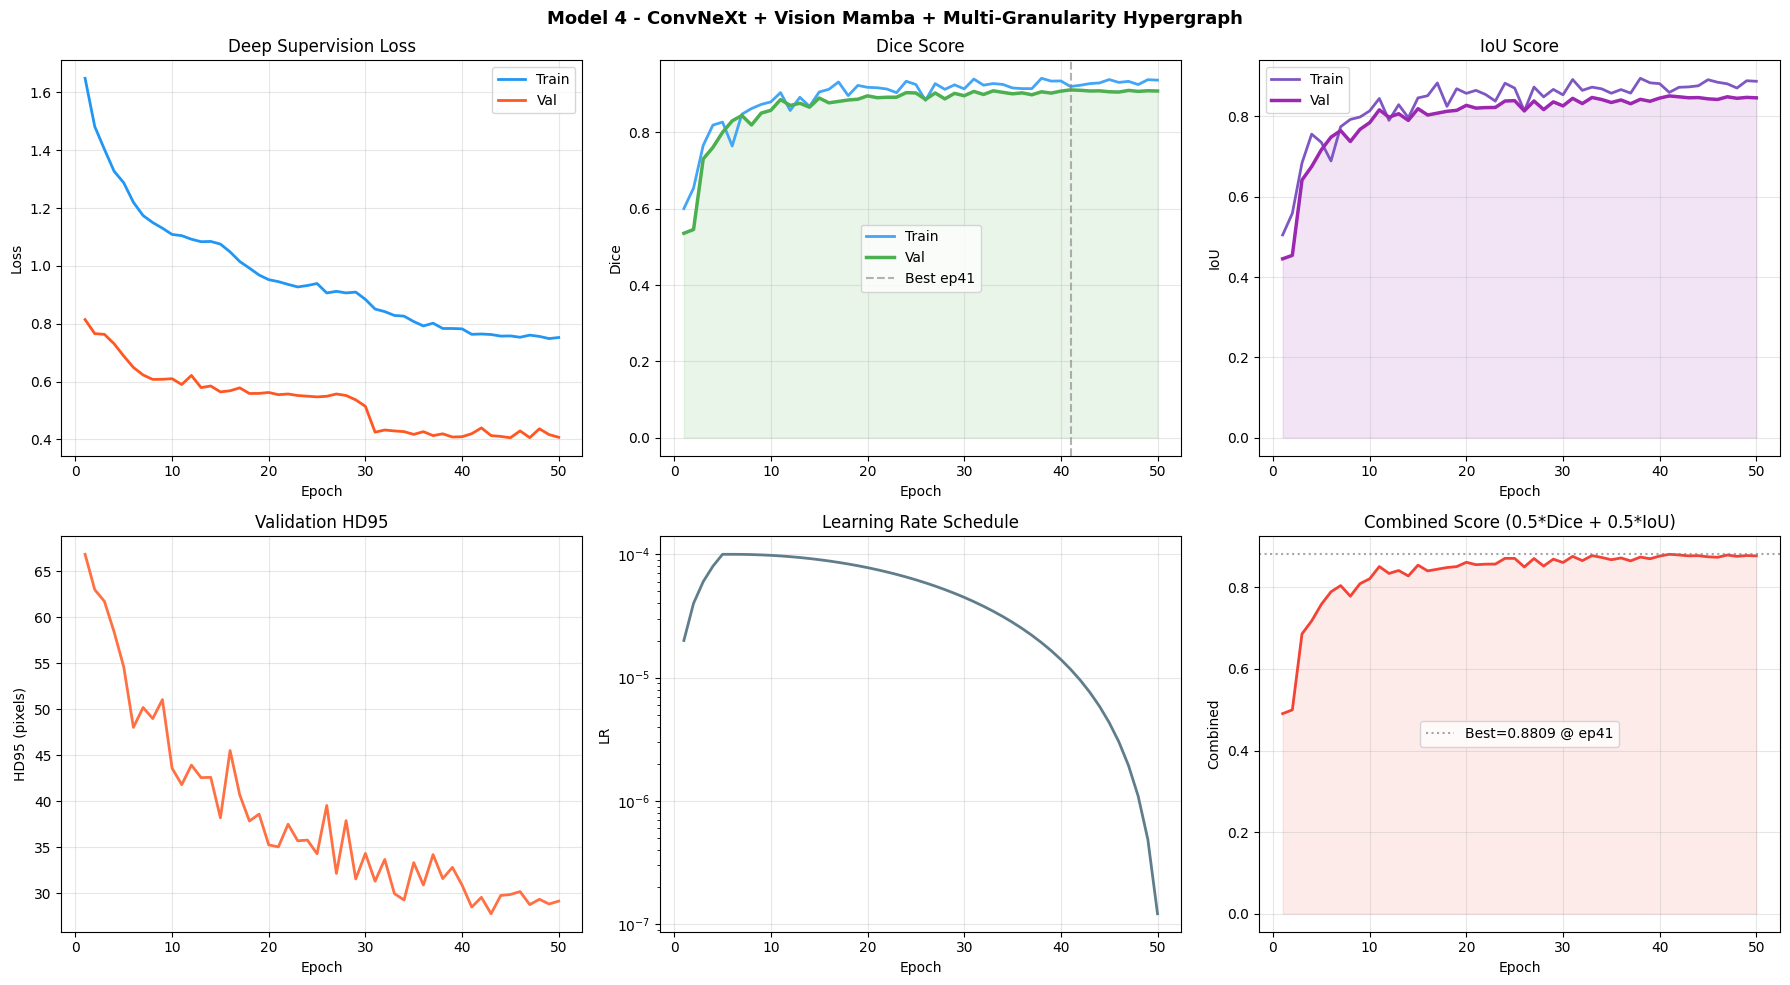

Saved training_curves_m4.png


In [9]:
ep=range(1,len(history["train_loss"])+1)
fig,axes=plt.subplots(2,3,figsize=(18,10))
fig.suptitle("Model 4 - ConvNeXt + Vision Mamba + Multi-Granularity Hypergraph",
             fontsize=13,fontweight="bold")
axes[0,0].plot(ep,history["train_loss"],label="Train",color="#2196F3",linewidth=2)
axes[0,0].plot(ep,history["val_loss"],  label="Val",  color="#FF5722",linewidth=2)
axes[0,0].set_title("Deep Supervision Loss"); axes[0,0].set_xlabel("Epoch")
axes[0,0].set_ylabel("Loss"); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)
axes[0,1].plot(ep,history["train_dice"],label="Train",color="#42A5F5",linewidth=2)
axes[0,1].plot(ep,history["val_dice"],  label="Val",  color="#4CAF50",linewidth=2.5)
axes[0,1].fill_between(ep,history["val_dice"],alpha=0.12,color="#4CAF50")
best_e=int(np.argmax(history["val_dice"]))
axes[0,1].axvline(best_e+1,color="gray",linestyle="--",alpha=0.6,label=f"Best ep{best_e+1}")
axes[0,1].set_title("Dice Score"); axes[0,1].set_xlabel("Epoch")
axes[0,1].set_ylabel("Dice"); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)
axes[0,2].plot(ep,history["train_iou"],label="Train",color="#7E57C2",linewidth=2)
axes[0,2].plot(ep,history["val_iou"],  label="Val",  color="#9C27B0",linewidth=2.5)
axes[0,2].fill_between(ep,history["val_iou"],alpha=0.12,color="#9C27B0")
axes[0,2].set_title("IoU Score"); axes[0,2].set_xlabel("Epoch")
axes[0,2].set_ylabel("IoU"); axes[0,2].legend(); axes[0,2].grid(alpha=0.3)
axes[1,0].plot(ep,history["val_hd95"],color="#FF7043",linewidth=2)
axes[1,0].set_title("Validation HD95"); axes[1,0].set_xlabel("Epoch")
axes[1,0].set_ylabel("HD95 (pixels)"); axes[1,0].grid(alpha=0.3)
axes[1,1].plot(ep,history["lr"],color="#607D8B",linewidth=2)
axes[1,1].set_title("Learning Rate Schedule"); axes[1,1].set_xlabel("Epoch")
axes[1,1].set_ylabel("LR"); axes[1,1].set_yscale("log"); axes[1,1].grid(alpha=0.3)
comb=[0.5*d+0.5*i for d,i in zip(history["val_dice"],history["val_iou"])]
axes[1,2].plot(ep,comb,color="#F44336",linewidth=2)
axes[1,2].fill_between(ep,comb,alpha=0.1,color="#F44336")
axes[1,2].axhline(max(comb),color="gray",linestyle=":",alpha=0.7,
                  label=f"Best={max(comb):.4f} @ ep{int(np.argmax(comb))+1}")
axes[1,2].set_title("Combined Score (0.5*Dice + 0.5*IoU)")
axes[1,2].set_xlabel("Epoch"); axes[1,2].set_ylabel("Combined")
axes[1,2].legend(); axes[1,2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_curves_m4.png",dpi=120,bbox_inches="tight"); plt.show()
print("Saved training_curves_m4.png")


## 10. Test Set Evaluation (EMA + 6-fold TTA)

In [10]:
model.load_state_dict(torch.load("best_model_model4.pth",map_location=DEVICE))
ema.apply(model)
test_metrics={"dice":[],"iou":[],"precision":[],"recall":[],"hd95":[]}
os.makedirs("test_predictions_m4",exist_ok=True)
all_imgs=[]; all_masks=[]; all_preds=[]
model.eval()
for i,(imgs,masks) in enumerate(test_loader):
    imgs=imgs.to(DEVICE)
    preds=tta_predict(model,imgs,n_aug=6)
    preds_bin=(preds>0.5).float()
    cv2.imwrite(f"test_predictions_m4/pred_{i:04d}.png",
                (preds_bin[0,0].cpu().numpy()*255).astype(np.uint8))
    if masks.sum()>0:
        masks_d=masks.to(DEVICE)
        la=torch.log(preds.clamp(1e-6,1-1e-6)/(1-preds.clamp(1e-6,1-1e-6)))
        m=compute_metrics(la,masks_d)
        for k in test_metrics: test_metrics[k].append(m[k])
    if masks.sum()>0 and len(all_imgs)<12:
        all_imgs.append(imgs[0].cpu()); all_masks.append(masks[0]); all_preds.append(preds_bin[0].cpu())
n_eval=len(test_metrics["dice"])
print("-"*62)
print("  Test Set Results  (EMA + 6-fold TTA)")
print("-"*62)
print(f"  {'Metric':<14} {'Mean':>8}  {'Std':>8}  {'Min':>8}  {'Max':>8}")
print("-"*62)
for k,v in test_metrics.items():
    arr=np.array(v)
    print(f"  {k.capitalize():<14} {arr.mean():>8.4f}  {arr.std():>8.4f}  {arr.min():>8.4f}  {arr.max():>8.4f}")
print("-"*62)
print(f"  Evaluated on {n_eval} labelled test samples")
print("-"*62)
ema.restore(model)


--------------------------------------------------------------
  Test Set Results  (EMA + 6-fold TTA)
--------------------------------------------------------------
  Metric             Mean       Std       Min       Max
--------------------------------------------------------------
  Dice             0.9007    0.1027    0.0000    0.9819
  Iou              0.8305    0.1225    0.0000    0.9645
  Precision        0.8558    0.1087    0.1974    1.0000
  Recall           0.9703    0.0851    0.0000    1.0000
  Hd95            28.6877   22.4376    0.0000  146.3749
--------------------------------------------------------------
  Evaluated on 168 labelled test samples
--------------------------------------------------------------


## 11. Metric Summary Chart

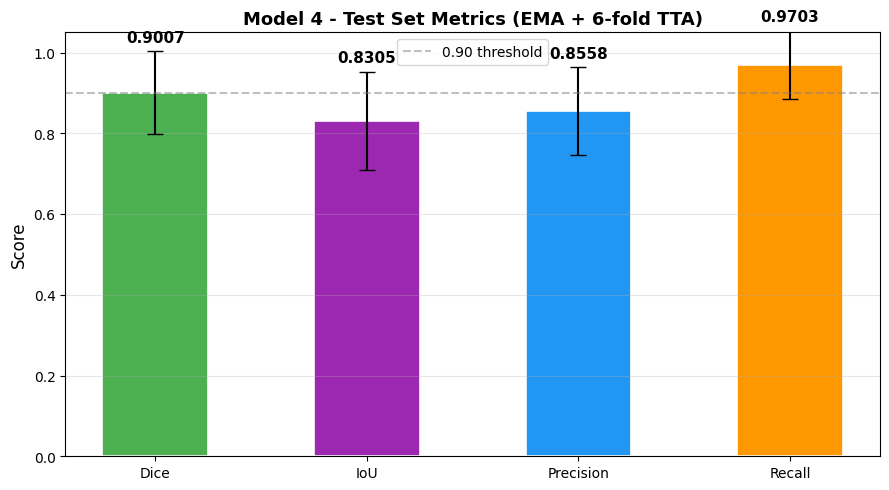

Saved metric_summary_m4.png


In [11]:
names = ["Dice","IoU","Precision","Recall"]
keys  = ["dice","iou","precision","recall"]
means = [np.mean(test_metrics[k]) for k in keys]
stds  = [np.std(test_metrics[k])  for k in keys]
cols  = ["#4CAF50","#9C27B0","#2196F3","#FF9800"]

fig, ax = plt.subplots(figsize=(9,5))
bars = ax.bar(names, means, yerr=stds, capsize=6,
              color=cols, edgecolor="white", linewidth=1.2, width=0.5)
ax.set_ylim(0, 1.05); ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model 4 - Test Set Metrics (EMA + 6-fold TTA)",
             fontsize=13, fontweight="bold")
ax.axhline(0.9, color="gray", linestyle="--", alpha=0.5, label="0.90 threshold")
for bar, mn, sd in zip(bars, means, stds):
    ax.text(bar.get_x()+bar.get_width()/2., mn+sd+0.015, f"{mn:.4f}",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("metric_summary_m4.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved metric_summary_m4.png")


## 12. Prediction Grid

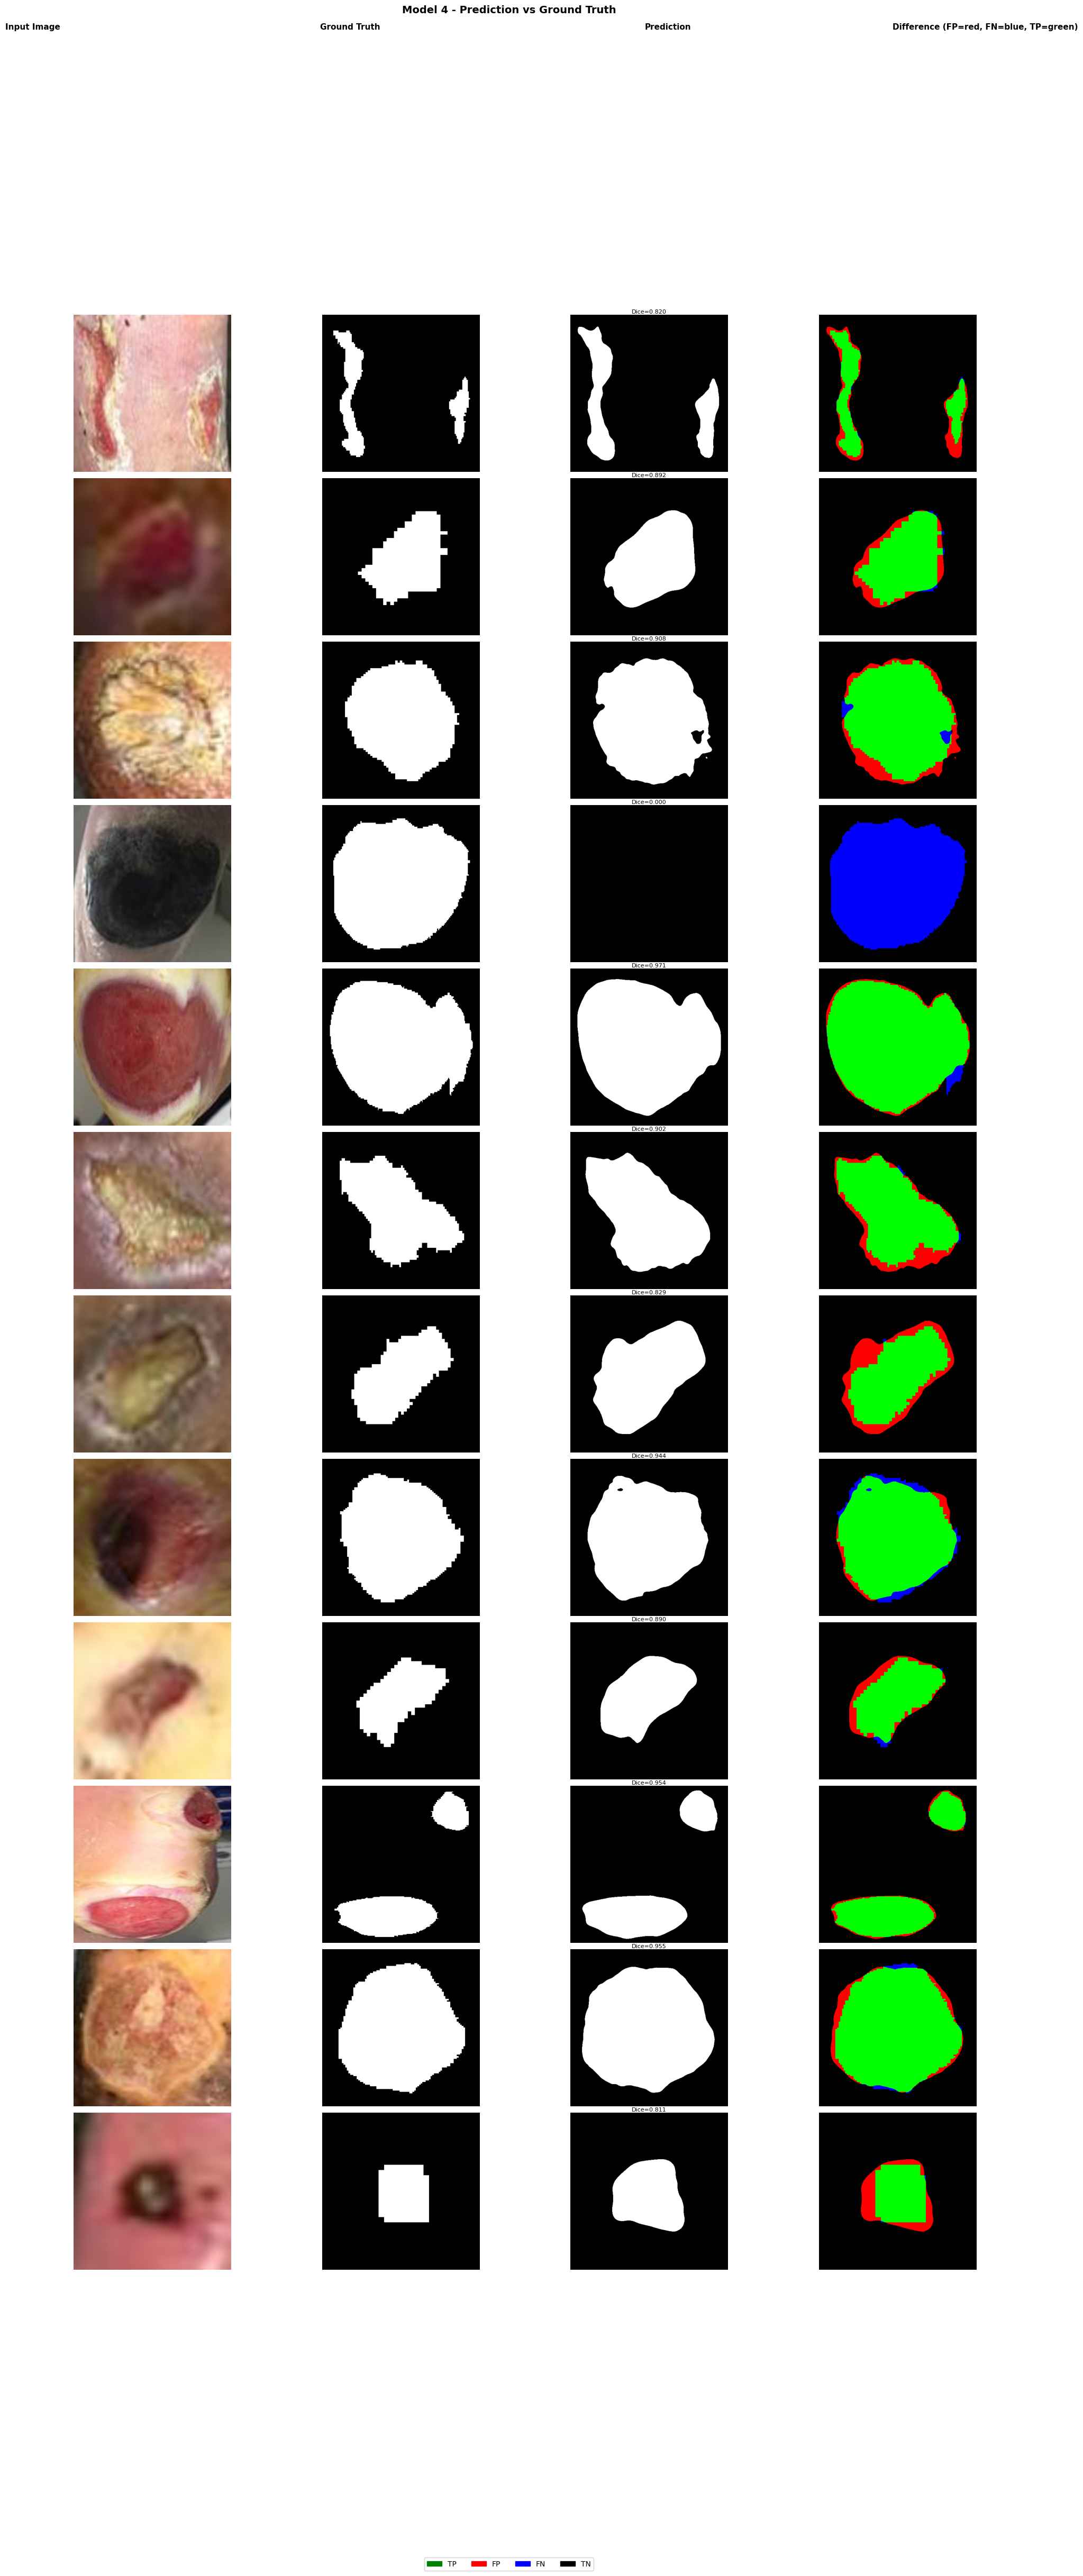

Saved prediction_grid_m4.png


In [12]:
n_show = min(len(all_imgs), 12)
fig    = plt.figure(figsize=(24, n_show*4))
gs     = GridSpec(n_show, 4, figure=fig, hspace=0.04, wspace=0.04)

for c, t in enumerate(["Input Image","Ground Truth","Prediction",
                        "Difference (FP=red, FN=blue, TP=green)"]):
    fig.text((c+0.5)/4., 0.995, t, ha="center", va="top",
             fontsize=11, fontweight="bold")

for row in range(n_show):
    img_np  = denorm(all_imgs[row])
    gt_np   = all_masks[row][0].numpy()
    pred_np = all_preds[row][0].numpy()
    diff    = np.zeros((*gt_np.shape,3))
    diff[(pred_np==1)&(gt_np==0)] = [1,0,0]
    diff[(pred_np==0)&(gt_np==1)] = [0,0,1]
    diff[(pred_np==1)&(gt_np==1)] = [0,1,0]

    for col, (data,cmap,vr) in enumerate([
            (img_np,None,None),(gt_np,"gray",(0,1)),
            (pred_np,"gray",(0,1)),(diff,None,None)]):
        ax = fig.add_subplot(gs[row,col])
        kw = dict(cmap=cmap) if cmap else {}
        if vr: kw.update(vmin=vr[0], vmax=vr[1])
        ax.imshow(data,**kw); ax.axis("off")
        if col == 2:
            pt = torch.tensor(pred_np).unsqueeze(0).unsqueeze(0)
            gt = torch.tensor(gt_np).unsqueeze(0).unsqueeze(0)
            d  = (2*(pt*gt).sum()+1)/(pt.sum()+gt.sum()+1)
            ax.set_title(f"Dice={d:.3f}", fontsize=8, pad=2)

patches = [mpatches.Patch(color="green",label="TP"),
           mpatches.Patch(color="red",  label="FP"),
           mpatches.Patch(color="blue", label="FN"),
           mpatches.Patch(color="black",label="TN")]
fig.legend(handles=patches, loc="lower center", ncol=4, fontsize=10,
           bbox_to_anchor=(0.5,-0.01), framealpha=0.9)
plt.suptitle("Model 4 - Prediction vs Ground Truth",
             fontsize=14, fontweight="bold", y=1.002)
plt.savefig("prediction_grid_m4.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved prediction_grid_m4.png")


## 13. Per-Sample Score Distribution

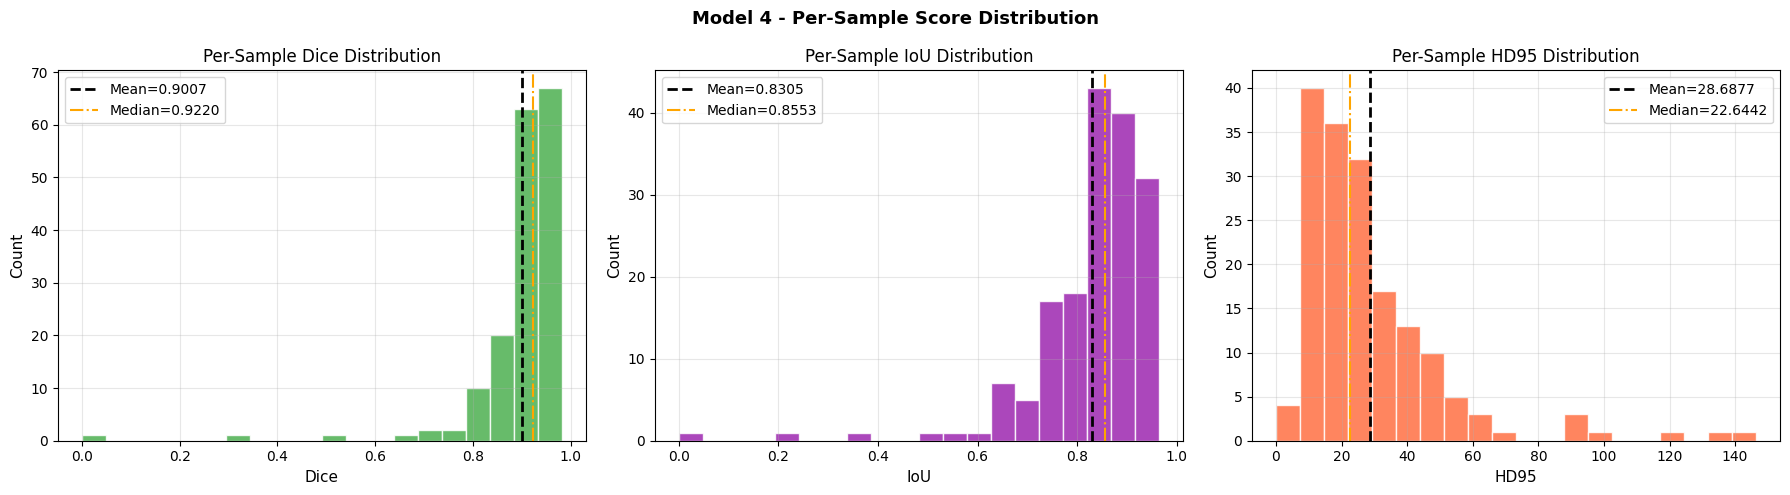

Saved score_distribution_m4.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle("Model 4 - Per-Sample Score Distribution",
             fontsize=13, fontweight="bold")

for ax, key, label, color in [
        (axes[0],"dice","Dice","#4CAF50"),
        (axes[1],"iou", "IoU", "#9C27B0"),
        (axes[2],"hd95","HD95","#FF7043")]:
    arr = np.array(test_metrics[key])
    ax.hist(arr, bins=20, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(arr.mean(),     color="black",  linestyle="--", linewidth=2,
               label=f"Mean={arr.mean():.4f}")
    ax.axvline(np.median(arr), color="orange", linestyle="-.", linewidth=1.5,
               label=f"Median={np.median(arr):.4f}")
    ax.set_xlabel(label, fontsize=11); ax.set_ylabel("Count", fontsize=11)
    ax.set_title(f"Per-Sample {label} Distribution")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("score_distribution_m4.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved score_distribution_m4.png")


## 14. Multi-Granularity Node Analysis

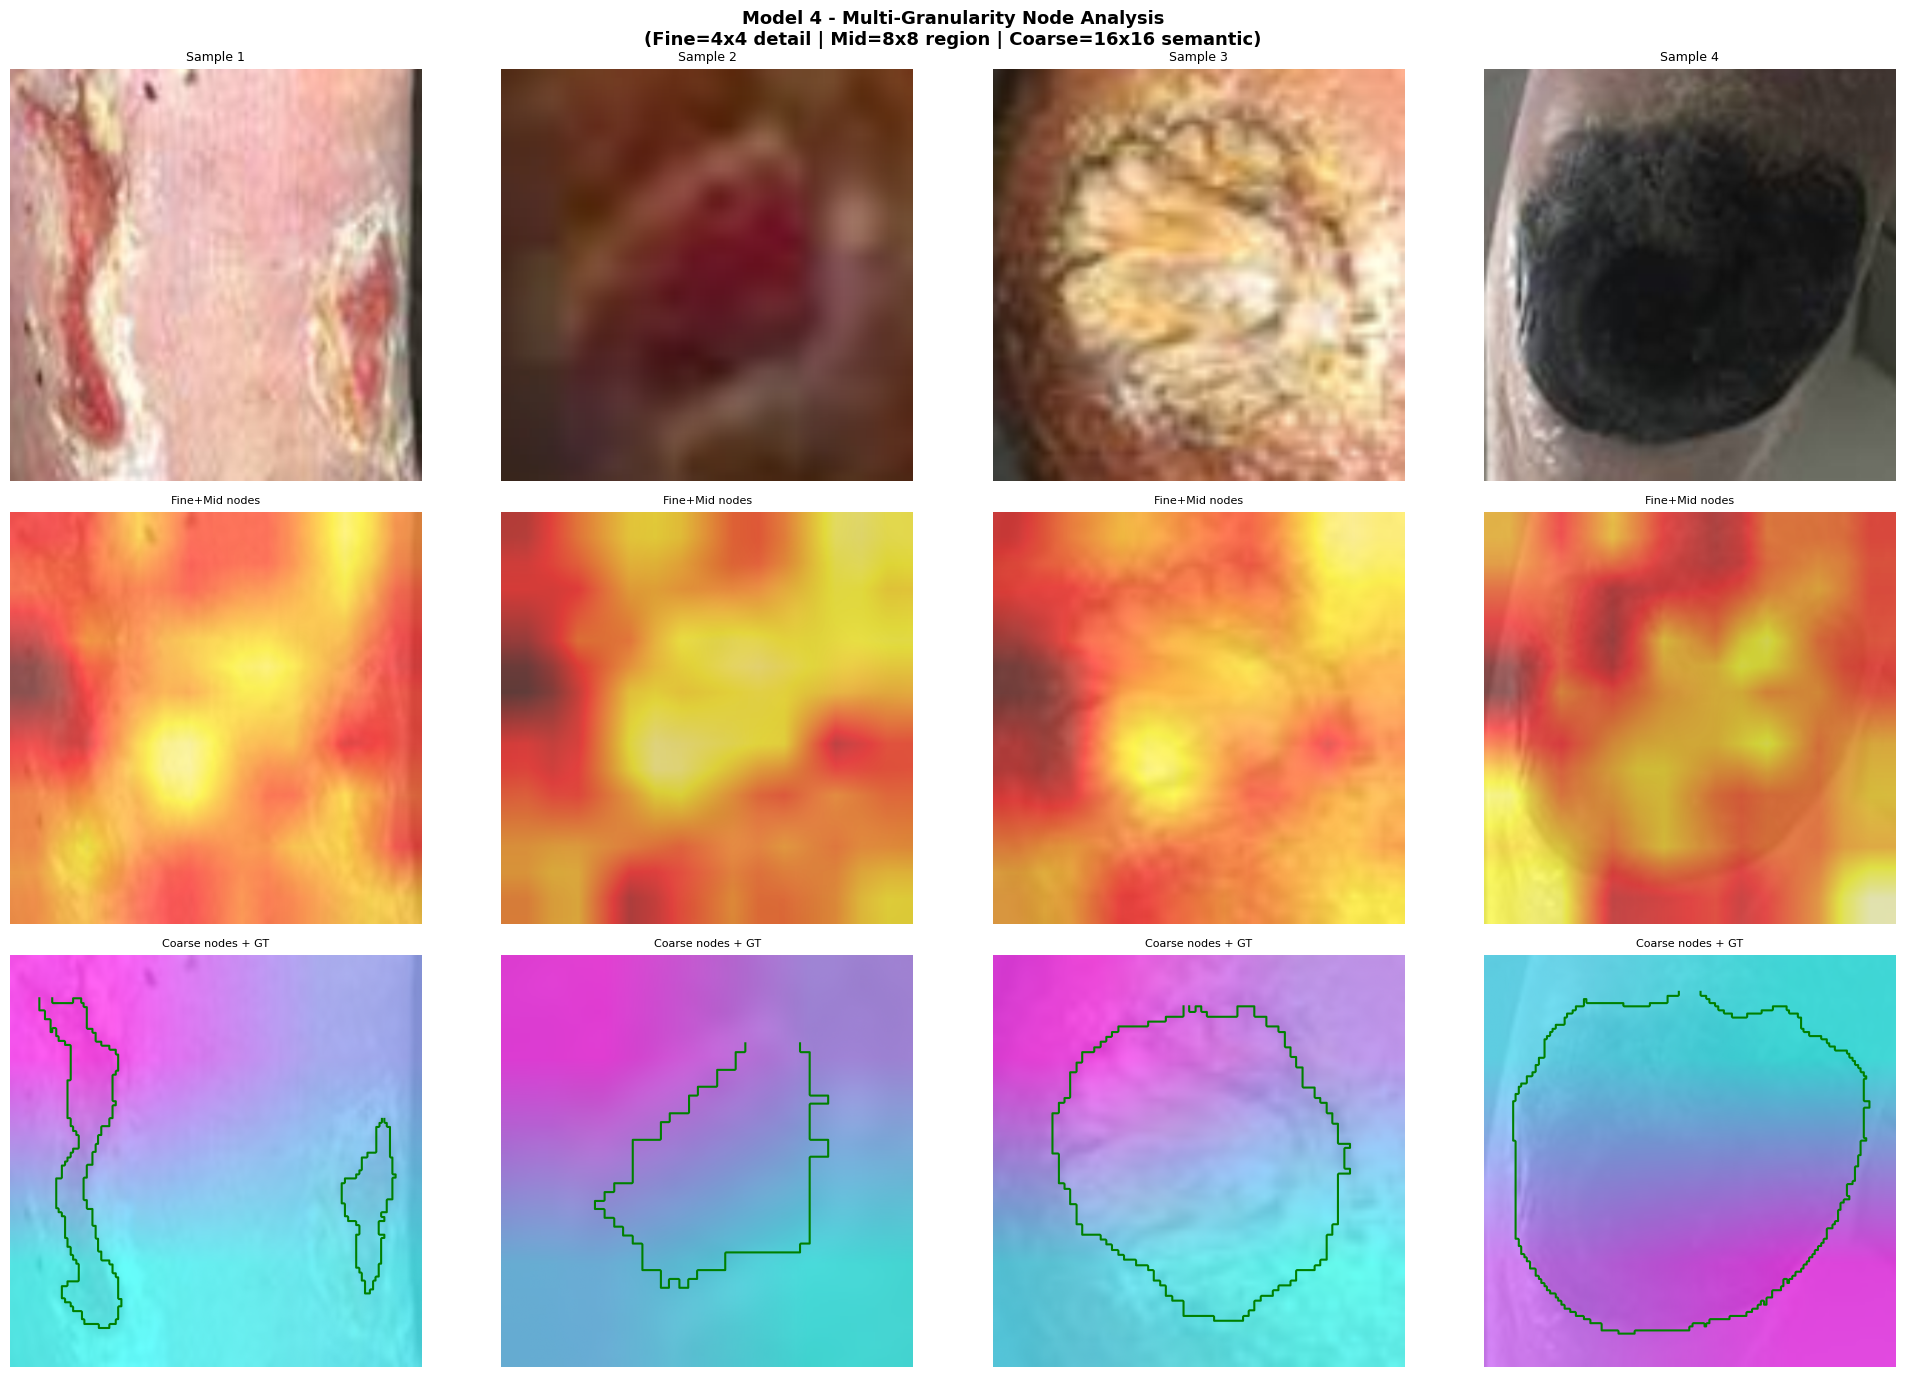

Saved granularity_analysis_m4.png


In [14]:
# Visualise what each granularity level captures
# Show node-level attention maps projected back to image space

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
fig.suptitle("Model 4 - Multi-Granularity Node Analysis\n"
             "(Fine=4x4 detail | Mid=8x8 region | Coarse=16x16 semantic)",
             fontsize=13, fontweight="bold")

ema.apply(model)
model.eval()

with torch.no_grad():
    for sample_i in range(min(4, len(all_imgs))):
        img_t  = all_imgs[sample_i].unsqueeze(0).to(DEVICE)
        gt_np  = all_masks[sample_i][0].numpy()
        img_np = denorm(all_imgs[sample_i])

        # Forward pass to get node embeddings
        f0, s1, s2, s3, f3 = model.encoder(img_t)
        fine_n   = model.fine_extractor(f0)
        mid_n    = model.mid_extractor(s1)
        coarse_n = model.coarse_extractor(s2)
        fine_n   = model._adj_nodes(fine_n,   model.n_fine)
        mid_n    = model._adj_nodes(mid_n,    model.n_mid)
        coarse_n = model._adj_nodes(coarse_n, model.n_coarse)

        # Node activation magnitude as attention proxy
        fine_act   = fine_n[0].norm(dim=-1).cpu().numpy()     # [N_FINE]
        mid_act    = mid_n[0].norm(dim=-1).cpu().numpy()      # [N_MID]
        coarse_act = coarse_n[0].norm(dim=-1).cpu().numpy()   # [N_COARSE]

        def nodes_to_heatmap(act, n_nodes, img_h=IMG_SIZE, img_w=IMG_SIZE):
            g = int(round(n_nodes**0.5))
            act_norm = (act - act.min())/(act.max()-act.min()+1e-8)
            grid = act_norm[:g*g].reshape(g,g)
            return cv2.resize(grid.astype(np.float32),(img_w,img_h),
                              interpolation=cv2.INTER_LINEAR)

        fine_hm   = nodes_to_heatmap(fine_act,   model.n_fine)
        mid_hm    = nodes_to_heatmap(mid_act,    model.n_mid)
        coarse_hm = nodes_to_heatmap(coarse_act, model.n_coarse)

        # Row 0: input image
        axes[0,sample_i].imshow(img_np)
        axes[0,sample_i].set_title(f"Sample {sample_i+1}", fontsize=9)
        axes[0,sample_i].axis("off")

        # Row 1: fine + mid overlay
        blend = 0.5*fine_hm + 0.5*mid_hm
        axes[1,sample_i].imshow(img_np, alpha=0.5)
        axes[1,sample_i].imshow(blend, cmap="hot", alpha=0.6,
                                 vmin=0, vmax=1)
        axes[1,sample_i].set_title("Fine+Mid nodes", fontsize=8)
        axes[1,sample_i].axis("off")

        # Row 2: coarse + GT contour
        axes[2,sample_i].imshow(img_np, alpha=0.5)
        axes[2,sample_i].imshow(coarse_hm, cmap="cool", alpha=0.6, vmin=0, vmax=1)
        contours, _ = cv2.findContours(gt_np.astype(np.uint8),
                                        cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in contours:
            c2d = c[:,0,:]
            axes[2,sample_i].plot(c2d[:,0], c2d[:,1], "g-", linewidth=1.5)
        axes[2,sample_i].set_title("Coarse nodes + GT", fontsize=8)
        axes[2,sample_i].axis("off")

axes[0,0].set_ylabel("Image",        fontsize=9, labelpad=4)
axes[1,0].set_ylabel("Fine+Mid",     fontsize=9, labelpad=4)
axes[2,0].set_ylabel("Coarse+GT",    fontsize=9, labelpad=4)

plt.tight_layout()
plt.savefig("granularity_analysis_m4.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved granularity_analysis_m4.png")
ema.restore(model)


## 15. Save Results Summary

In [15]:
summary = {
    "architecture": "ConvNeXt + Vision Mamba + Multi-Granularity Hypergraph + HierarchicalHGNN",
    "datasets":     ["Foot Ulcer Segmentation Challenge","Medetec_foot_ulcer"],
    "total_images": len(full_noaug),
    "split": {
        "train": len(train_sub.indices),
        "val":   len(val_sub.indices),
        "test":  len(test_sub.indices),
    },
    "hyperparameters": {
        "img_size":      IMG_SIZE,
        "batch_size":    BATCH_SIZE,
        "lr":            LR,
        "warmup_epochs": WARMUP_EPOCHS,
        "ema_decay":     EMA_DECAY,
        "patience":      PATIENCE,
        "dropout":       DROPOUT_RATE,
        "n_fine":        N_FINE,
        "n_mid":         N_MID,
        "n_coarse":      N_COARSE,
        "n_total":       N_TOTAL,
        "node_dim":      NODE_DIM,
        "loss":          "Deep Supervision: Boundary Dice + BCE (aux_weights=0.4,0.3,0.2)",
    },
    "training": {
        "epochs_run":    len(history["train_loss"]),
        "best_val_dice": float(best_dice),
        "best_val_iou":  float(best_iou),
        "best_combined": float(best_score),
    },
    "test_metrics": {
        k: {"mean":float(np.mean(v)),"std":float(np.std(v)),
            "min":float(np.min(v)), "max":float(np.max(v))}
        for k,v in test_metrics.items() if v
    },
    "training_history": {
        k: [float(x) for x in v] for k,v in history.items()
    },
}

with open("model4_results.json","w") as f:
    json.dump(summary, f, indent=2)

print("-"*64)
print("  MODEL 4 -- FINAL SUMMARY")
print("-"*64)
print(f"  Architecture   : ConvNeXt + Vision Mamba + Multi-Granularity Hypergraph")
print(f"  Datasets       : FUSC + Medetec  ({len(full_noaug)} total images)")
print(f"  Train/Val/Test : {len(train_sub.indices)} / {len(val_sub.indices)} / {len(test_sub.indices)}")
print(f"  IMG SIZE       : {IMG_SIZE}")
print(f"  Nodes          : fine={N_FINE} (4x4)  mid={N_MID} (8x8)  coarse={N_COARSE} (16x16)  total={N_TOTAL}")
print(f"  Epochs run     : {len(history['train_loss'])} / {NUM_EPOCHS}")
print(f"  Best Val Dice  : {best_dice:.4f}")
print(f"  Best Val IoU   : {best_iou:.4f}")
print(f"  Best Combined  : {best_score:.4f}")
if test_metrics["dice"]:
    print(f"  Test Dice      : {np.mean(test_metrics['dice']):.4f} +/- {np.std(test_metrics['dice']):.4f}")
    print(f"  Test IoU       : {np.mean(test_metrics['iou']):.4f} +/- {np.std(test_metrics['iou']):.4f}")
    print(f"  Test Precision : {np.mean(test_metrics['precision']):.4f}")
    print(f"  Test Recall    : {np.mean(test_metrics['recall']):.4f}")
    print(f"  Test HD95      : {np.mean(test_metrics['hd95']):.2f} px")
print("-"*64)
print("  Saved: best_model_model4.pth  last_checkpoint_model4.pth")
print("         model4_results.json    training_curves_m4.png")
print("         metric_summary_m4.png   prediction_grid_m4.png")
print("         score_distribution_m4.png  granularity_analysis_m4.png")
print("         test_predictions_m4/")
print("-"*64)


----------------------------------------------------------------
  MODEL 4 -- FINAL SUMMARY
----------------------------------------------------------------
  Architecture   : ConvNeXt + Vision Mamba + Multi-Granularity Hypergraph
  Datasets       : FUSC + Medetec  (1370 total images)
  Train/Val/Test : 913 / 228 / 229
  IMG SIZE       : 512
  Nodes          : fine=64 (4x4)  mid=16 (8x8)  coarse=4 (16x16)  total=84
  Epochs run     : 50 / 50
  Best Val Dice  : 0.9111
  Best Val IoU   : 0.8508
  Best Combined  : 0.8809
  Test Dice      : 0.9007 +/- 0.1027
  Test IoU       : 0.8305 +/- 0.1225
  Test Precision : 0.8558
  Test Recall    : 0.9703
  Test HD95      : 28.69 px
----------------------------------------------------------------
  Saved: best_model_model4.pth  last_checkpoint_model4.pth
         model4_results.json    training_curves_m4.png
         metric_summary_m4.png   prediction_grid_m4.png
         score_distribution_m4.png  granularity_analysis_m4.png
         test_predictio

## 16. Test-Set Scoring Policy for Empty-Mask Images

The original evaluation loop scores only images where `masks.sum() > 0`, silently dropping wound-free images. This cell re-evaluates the full test set - including wound-free images (scored as perfect when both prediction and GT are empty, penalised when the model hallucinates a wound) - and prints both numbers side-by-side for the paper.

In [16]:
model.load_state_dict(torch.load("best_model_model4.pth", map_location=DEVICE))
ema.apply(model)
model.eval()

full_test_metrics = {"dice": [], "iou": [], "precision": [], "recall": [], "hd95": []}
n_empty_gt = 0

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs = imgs.to(DEVICE)
        preds = tta_predict(model, imgs, n_aug=6)
        if masks.sum() == 0:
            n_empty_gt += 1
        masks_d = masks.to(DEVICE)
        la = torch.log(preds.clamp(1e-6, 1-1e-6) / (1 - preds.clamp(1e-6, 1-1e-6)))
        m  = compute_metrics(la, masks_d)
        for k in full_test_metrics:
            full_test_metrics[k].append(m[k])

ema.restore(model)

print(f"Lesion-only test images   : {len(test_metrics['dice'])}")
print(f"Wound-free (empty GT)     : {n_empty_gt}")
print(f"Full test set             : {len(full_test_metrics['dice'])}")
print()
print(f"{'Metric':<12} {'Lesion-only':>14} {'Full test set':>16}")
print("-" * 44)
for k in full_test_metrics:
    lo = np.mean(test_metrics[k]) if test_metrics[k] else float('nan')
    fu = np.mean(full_test_metrics[k])
    print(f"{k.capitalize():<12} {lo:>14.4f} {fu:>16.4f}")

with open("model4_full_test_metrics.json", "w") as f:
    json.dump({k: [float(x) for x in v] for k, v in full_test_metrics.items()}, f, indent=2)
print("\nSaved model4_full_test_metrics.json")


Lesion-only test images   : 168
Wound-free (empty GT)     : 61
Full test set             : 229

Metric          Lesion-only    Full test set
--------------------------------------------
Dice                 0.9007           0.9272
Iou                  0.8305           0.8757
Precision            0.8558           0.8942
Recall               0.9703           0.9782
Hd95                28.6877          21.0460

Saved model4_full_test_metrics.json


## 17. Bootstrap 95% Confidence Intervals

10,000-resample bootstrap CIs on the per-sample test metrics. No retraining - reuses the `test_metrics` arrays from Section 10.

In [17]:
def bootstrap_ci(values, n_boot=10000, ci=95, seed=SEED):
    values = np.asarray(values, dtype=np.float64)
    rng = np.random.default_rng(seed)
    boot_means = np.array([values[rng.integers(0, len(values), len(values))].mean()
                           for _ in range(n_boot)])
    lo = np.percentile(boot_means, (100-ci)/2)
    hi = np.percentile(boot_means, 100-(100-ci)/2)
    return values.mean(), lo, hi

ci_results = {}
print(f"{'Metric':<12} {'Mean':>8}  {'95% CI':>22}")
print("-" * 48)
for k, v in test_metrics.items():
    mean, lo, hi = bootstrap_ci(v)
    ci_results[k] = {"mean": float(mean), "ci_low": float(lo), "ci_high": float(hi)}
    print(f"{k.capitalize():<12} {mean:>8.4f}  [{lo:.4f}, {hi:.4f}]")

with open("model4_bootstrap_ci.json", "w") as f:
    json.dump(ci_results, f, indent=2)
print(f"\nSaved model4_bootstrap_ci.json")
print(f"\nPaper format: Dice = {ci_results['dice']['mean']:.4f} "
      f"(95% CI: {ci_results['dice']['ci_low']:.4f}–{ci_results['dice']['ci_high']:.4f})")


Metric           Mean                  95% CI
------------------------------------------------
Dice           0.9007  [0.8833, 0.9146]
Iou            0.8305  [0.8108, 0.8478]
Precision      0.8558  [0.8387, 0.8717]
Recall         0.9703  [0.9550, 0.9803]
Hd95          28.6877  [25.4602, 32.2319]

Saved model4_bootstrap_ci.json

Paper format: Dice = 0.9007 (95% CI: 0.8833–0.9146)


## 18. Model Complexity and Runtime Analysis

Parameter count by module, FLOPs (via `thop`), and measured inference latency/FPS. Model 4 is the heaviest architecture (multi-granularity extractors + hierarchical HGNN + deep supervision decoder), so runtime is part of the contribution story.

In [18]:
!pip install thop --break-system-packages -q

try:
    from thop import profile as _thop_profile
    _HAS_THOP = True
except ImportError:
    _HAS_THOP = False
    print("[warning] thop not available - FLOPs skipped.")

import time

model.eval()

modules = [
    ("encoder (ConvNeXt+Mamba stages)",    model.encoder),
    ("fine_extractor (GranularityNode)",   model.fine_extractor),
    ("mid_extractor  (GranularityNode)",   model.mid_extractor),
    ("coarse_extractor (GranularityNode)", model.coarse_extractor),
    ("hgnn (HierarchicalHGNN)",            model.hgnn),
    ("sym_fusion (WoundAnatomyFusion)",    model.sym_fusion),
    ("decoder (MultiScaleDecoder)",        model.decoder),
]

print("Parameter count by module:")
print("-" * 46)
module_params = {}
for name, mod in modules:
    n = sum(p.numel() for p in mod.parameters())
    module_params[name] = n
    print(f"  {name:<38} {n/1e6:>7.3f} M")
total = sum(module_params.values())
print("-" * 46)
print(f"  {'TOTAL':<38} {total/1e6:>7.3f} M")

dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
flops_g = None
if _HAS_THOP:
    with torch.no_grad():
        macs, _ = _thop_profile(model, inputs=(dummy,), verbose=False)
    flops_g = macs * 2 / 1e9

    # Clean up thop buffers so they do not corrupt EMA state
    for m in model.modules():
        if hasattr(m, "total_ops"):    del m.total_ops
        if hasattr(m, "total_params"): del m.total_params
    print(f"\nFLOPs ({IMG_SIZE}x{IMG_SIZE} input): {flops_g:.2f} GFLOPs")

# Warmup then measure
n_warmup, n_runs = 10, 50
model.eval()
with torch.no_grad():
    for _ in range(n_warmup): _ = model(dummy)
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n_runs): _ = model(dummy)
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    t1 = time.perf_counter()

latency_ms = (t1 - t0) / n_runs * 1000
fps = 1000.0 / latency_ms
print(f"\nInference latency (single image, no TTA): {latency_ms:.2f} ms  ({fps:.2f} FPS)")
print(f"With 6-fold TTA (as used at test time):  ~{latency_ms*6:.2f} ms")

eff = {"total_params_M": total/1e6,
       "module_params_M": {k: v/1e6 for k,v in module_params.items()},
       "flops_G": flops_g,
       "latency_ms": latency_ms, "fps": fps,
       "latency_ms_tta6": latency_ms*6,
       "img_size": IMG_SIZE, "device": str(DEVICE)}
with open("model4_efficiency.json", "w") as f:
    json.dump(eff, f, indent=2)
print("Saved model4_efficiency.json")


Parameter count by module:
----------------------------------------------
  encoder (ConvNeXt+Mamba stages)         23.749 M
  fine_extractor (GranularityNode)         0.042 M
  mid_extractor  (GranularityNode)         0.054 M
  coarse_extractor (GranularityNode)       0.100 M
  hgnn (HierarchicalHGNN)                  1.977 M
  sym_fusion (WoundAnatomyFusion)          0.657 M
  decoder (MultiScaleDecoder)              9.173 M
----------------------------------------------
  TOTAL                                   35.753 M

FLOPs (512x512 input): 111.56 GFLOPs

Inference latency (single image, no TTA): 40.55 ms  (24.66 FPS)
With 6-fold TTA (as used at test time):  ~243.32 ms
Saved model4_efficiency.json


## 19. Explainability - Symbolic Fusion Gates and Granularity Attention

Model 4's symbolic component is `WoundAnatomySymbolicFusion`, which uses four learnable gates to route information between fine, mid, and coarse granularity levels. This cell hooks into each gate and visualises (a) gate activation distributions and (b) per-node activation magnitudes at each granularity projected back to image space - the evidence that the multi-granularity structure is doing real anatomical work.

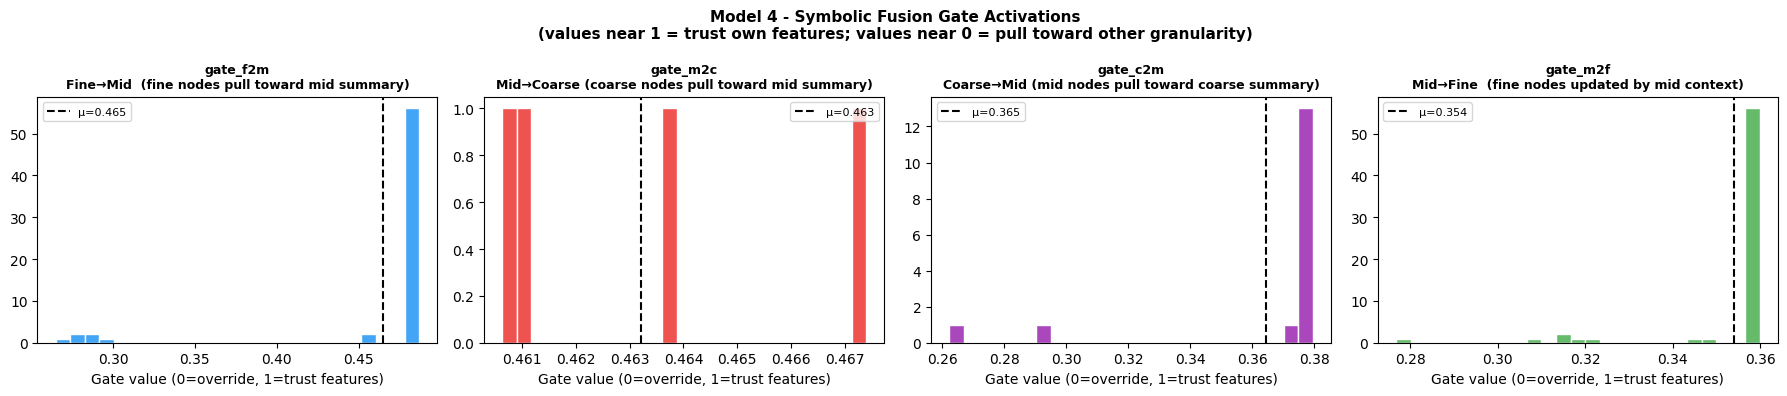

Gate mean values:
  gate_f2m: 0.4647 → pulls toward other granularity
  gate_m2c: 0.4632 → pulls toward other granularity
  gate_c2m: 0.3646 → pulls toward other granularity
  gate_m2f: 0.3539 → pulls toward other granularity

Saved symbolic_gates_m4.png


In [19]:
# Hook all four symbolic gates
_gate_outputs = {}

def _make_hook(name):
    def _hook(module, inp, out):
        _gate_outputs[name] = out.detach().cpu()
    return _hook

handles = [
    model.sym_fusion.gate_f2m.register_forward_hook(_make_hook("gate_f2m")),
    model.sym_fusion.gate_m2c.register_forward_hook(_make_hook("gate_m2c")),
    model.sym_fusion.gate_c2m.register_forward_hook(_make_hook("gate_c2m")),
    model.sym_fusion.gate_m2f.register_forward_hook(_make_hook("gate_m2f")),
]

ema.apply(model)
model.eval()
sample_imgs, sample_masks = next(iter(test_loader))
sample_imgs = sample_imgs.to(DEVICE)
with torch.no_grad():
    _ = model(sample_imgs)
for h in handles: h.remove()
ema.restore(model)

gate_labels = {
    "gate_f2m": "Fine→Mid  (fine nodes pull toward mid summary)",
    "gate_m2c": "Mid→Coarse (coarse nodes pull toward mid summary)",
    "gate_c2m": "Coarse→Mid (mid nodes pull toward coarse summary)",
    "gate_m2f": "Mid→Fine  (fine nodes updated by mid context)",
}
gate_colors = {"gate_f2m": "#42A5F5", "gate_m2c": "#EF5350",
               "gate_c2m": "#AB47BC", "gate_m2f": "#66BB6A"}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, label) in zip(axes, gate_labels.items()):
    vals = _gate_outputs[name].mean(-1).numpy().flatten()   # mean over NODE_DIM
    ax.hist(vals, bins=25, color=gate_colors[name], edgecolor="white")
    ax.axvline(vals.mean(), color="black", linestyle="--", label=f"μ={vals.mean():.3f}")
    ax.set_title(f"{name}\n{label}", fontsize=9, fontweight="bold")
    ax.set_xlabel("Gate value (0=override, 1=trust features)")
    ax.legend(fontsize=8)
plt.suptitle("Model 4 - Symbolic Fusion Gate Activations\n"
             "(values near 1 = trust own features; values near 0 = pull toward other granularity)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("symbolic_gates_m4.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gate mean values:")
for name in gate_labels:
    v = _gate_outputs[name].mean().item()
    direction = "trusts own features" if v > 0.5 else "pulls toward other granularity"
    print(f"  {name}: {v:.4f} → {direction}")
print("\nSaved symbolic_gates_m4.png")


## 20. Multi-Granularity Hypergraph Visualization

Model 4's hypergraph is unique across all four models: it has **three granularity levels** of nodes (fine=64 at 4×4 patches, mid=16 at 8×8, coarse=4 at 16×16), each extracted from a different encoder stage and connected via cross-scale edges. This section produces:

**(a)** Spatial overlay - all three granularity levels plotted on the wound image at their correct pixel positions, sized by granularity.

**(b)** Cross-scale edge diagram - fine↔mid↔coarse hierarchy drawn explicitly.

**(c)** Abstract schematic for the Methodology section.

In [20]:
try:
    import networkx as nx
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable,"-m","pip","install","networkx","--break-system-packages"],check=True)
    import networkx as nx

# ── Recover pixel-space positions for each granularity level ──────────────
# Fine:   extracted from f0 (stem, stride=4), then AdaptiveAvgPool2d(8) → 8x8 grid
#         Each node covers IMG_SIZE/8 = 64 px
# Mid:    extracted from s1 (stage1 skip = same spatial res as f0, stride=4),
#         then AdaptiveAvgPool2d(4) → 4x4 grid, each node covers IMG_SIZE/4 = 128 px
# Coarse: extracted from s2 (stage2 skip, stride=4*2=8),
#         then AdaptiveAvgPool2d(2) → 2x2 grid, each node covers IMG_SIZE/2 = 256 px

fine_g   = int(N_FINE**0.5)        # 8
mid_g    = math.ceil(N_MID**0.5)   # 4
coarse_g = math.ceil(N_COARSE**0.5) # 2

fine_step   = IMG_SIZE // fine_g    # 64
mid_step    = IMG_SIZE // mid_g     # 128
coarse_step = IMG_SIZE // coarse_g  # 256

fine_px   = [(j*fine_step   + fine_step//2,   i*fine_step   + fine_step//2)
             for i in range(fine_g)   for j in range(fine_g)]
mid_px    = [(j*mid_step    + mid_step//2,    i*mid_step    + mid_step//2)
             for i in range(mid_g)    for j in range(mid_g)]
coarse_px = [(j*coarse_step + coarse_step//2, i*coarse_step + coarse_step//2)
             for i in range(coarse_g) for j in range(coarse_g)]

fine_px_x,   fine_px_y   = zip(*fine_px)
mid_px_x,    mid_px_y    = zip(*mid_px)
coarse_px_x, coarse_px_y = zip(*coarse_px)

print(f"Fine   : {len(fine_px)} nodes, {fine_step}px per cell")
print(f"Mid    : {len(mid_px)} nodes, {mid_step}px per cell")
print(f"Coarse : {len(coarse_px)} nodes, {coarse_step}px per cell")


Fine   : 64 nodes, 64px per cell
Mid    : 16 nodes, 128px per cell
Coarse : 4 nodes, 256px per cell


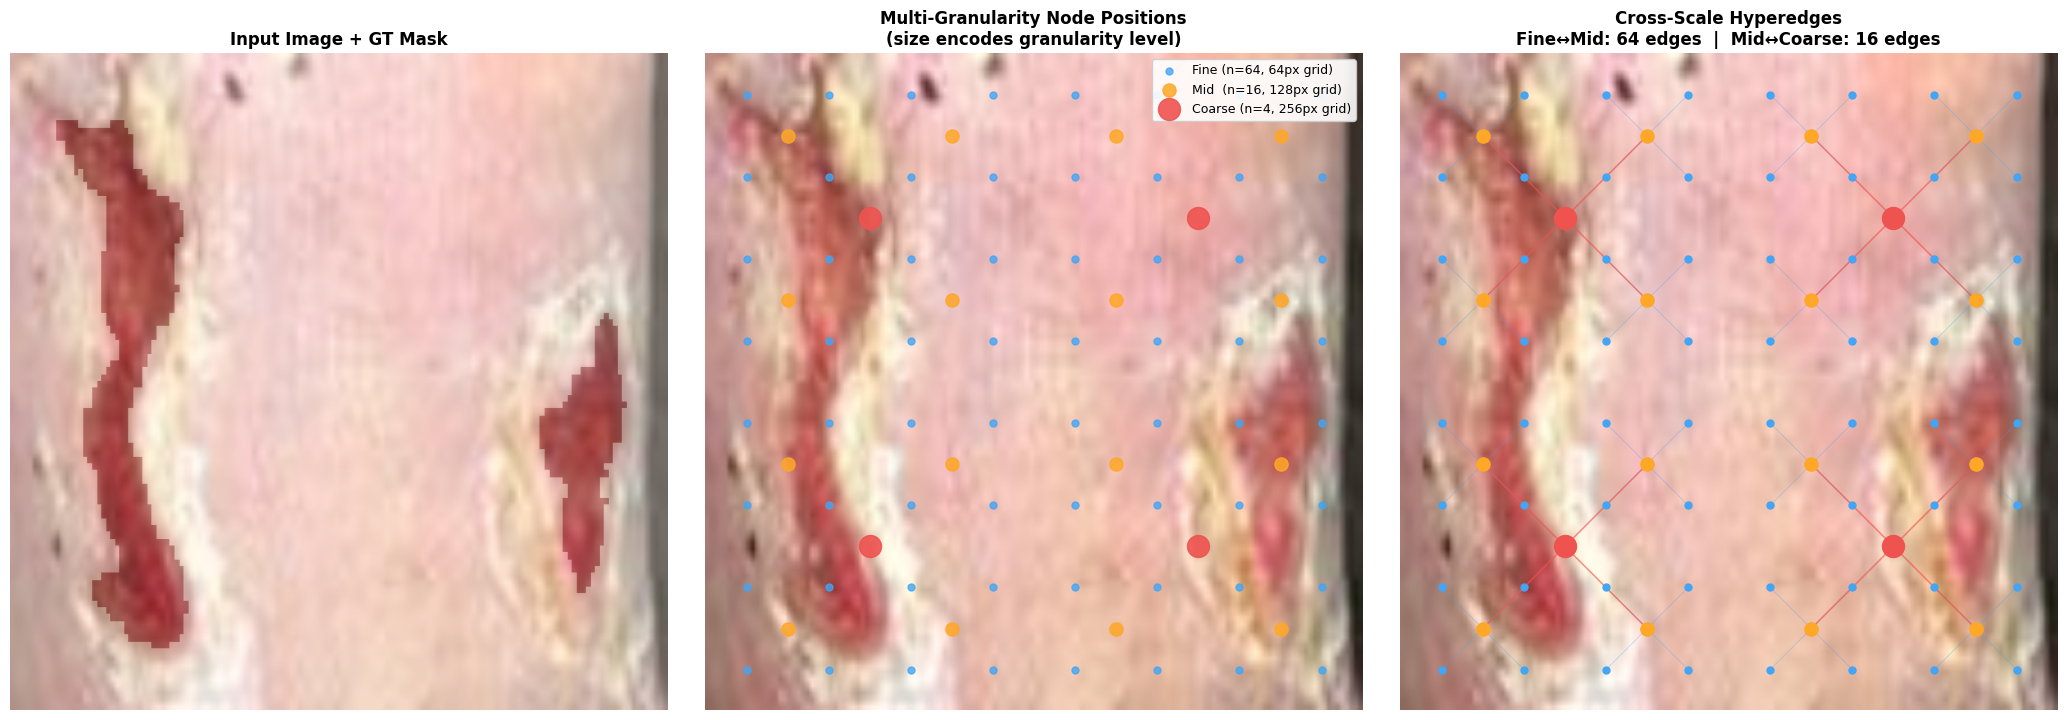

Saved hypergraph_spatial_overlay_m4.png


In [21]:
# Pick a clear representative test image
ema.apply(model)
model.eval()
viz_img, viz_mask = None, None
for imgs, masks in test_loader:
    if masks[0].sum() > 500:
        viz_img, viz_mask = imgs[0], masks[0]
        break

img_np_viz  = denorm(viz_img)
mask_np_viz = viz_mask[0].numpy()

# Get actual adjacency matrix from a real forward pass
with torch.no_grad():
    f0,s1,s2,s3,f3 = model.encoder(viz_img.unsqueeze(0).to(DEVICE))
    fine_n   = model._adj_nodes(model.fine_extractor(f0),   model.n_fine)
    mid_n    = model._adj_nodes(model.mid_extractor(s1),    model.n_mid)
    coarse_n = model._adj_nodes(model.coarse_extractor(s2), model.n_coarse)
    adj = build_multigranularity_hypergraph(
              fine_n, mid_n, coarse_n, N_FINE, N_MID, N_COARSE).cpu().numpy()

ema.restore(model)

# Partition the adjacency matrix into sub-blocks
A_ff = adj[:N_FINE,          :N_FINE]
A_mm = adj[N_FINE:N_FINE+N_MID, N_FINE:N_FINE+N_MID]
A_cc = adj[N_FINE+N_MID:,       N_FINE+N_MID:]
A_fm = adj[:N_FINE,            N_FINE:N_FINE+N_MID]  # fine<->mid
A_mc = adj[N_FINE:N_FINE+N_MID, N_FINE+N_MID:]       # mid<->coarse

# ── Figure (a): 3-panel spatial overlay ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

# Panel 1: image + GT
axes[0].imshow(img_np_viz)
axes[0].imshow(mask_np_viz, cmap="Reds", alpha=0.3)
axes[0].set_title("Input Image + GT Mask", fontsize=12, fontweight="bold")
axes[0].axis("off")

# Panel 2: all three granularity node sets
axes[1].imshow(img_np_viz)
axes[1].scatter(fine_px_x,   fine_px_y,   c="#42A5F5", s=25,  alpha=0.8,
                label=f"Fine (n={N_FINE}, {fine_step}px grid)", zorder=4)
axes[1].scatter(mid_px_x,    mid_px_y,    c="#FFA726", s=90,  alpha=0.85,
                label=f"Mid  (n={N_MID}, {mid_step}px grid)",  zorder=4)
axes[1].scatter(coarse_px_x, coarse_px_y, c="#EF5350", s=250, alpha=0.9,
                label=f"Coarse (n={N_COARSE}, {coarse_step}px grid)", zorder=4)
axes[1].set_title("Multi-Granularity Node Positions\n(size encodes granularity level)",
                   fontsize=12, fontweight="bold")
axes[1].legend(loc="upper right", fontsize=9, framealpha=0.9)
axes[1].axis("off")

# Panel 3: cross-scale edges (fine↔mid and mid↔coarse)
axes[2].imshow(img_np_viz)
fi_idx, mi_idx = np.where(A_fm > 0)
for fi, mi in zip(fi_idx, mi_idx):
    axes[2].plot([fine_px_x[fi], mid_px_x[mi]], [fine_px_y[fi], mid_px_y[mi]],
                 color="#42A5F5", lw=0.5, alpha=0.4, zorder=2)
mi_idx2, ci_idx = np.where(A_mc > 0)
for mi, ci in zip(mi_idx2, ci_idx):
    axes[2].plot([mid_px_x[mi], coarse_px_x[ci]], [mid_px_y[mi], coarse_px_y[ci]],
                 color="#EF5350", lw=1.2, alpha=0.6, zorder=2)
axes[2].scatter(fine_px_x,   fine_px_y,   c="#42A5F5", s=25,  zorder=4)
axes[2].scatter(mid_px_x,    mid_px_y,    c="#FFA726", s=90,  zorder=4)
axes[2].scatter(coarse_px_x, coarse_px_y, c="#EF5350", s=250, zorder=4)
axes[2].set_title(f"Cross-Scale Hyperedges\n"
                   f"Fine↔Mid: {int(A_fm.sum())} edges  |  Mid↔Coarse: {int(A_mc.sum())} edges",
                   fontsize=12, fontweight="bold")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("hypergraph_spatial_overlay_m4.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved hypergraph_spatial_overlay_m4.png")


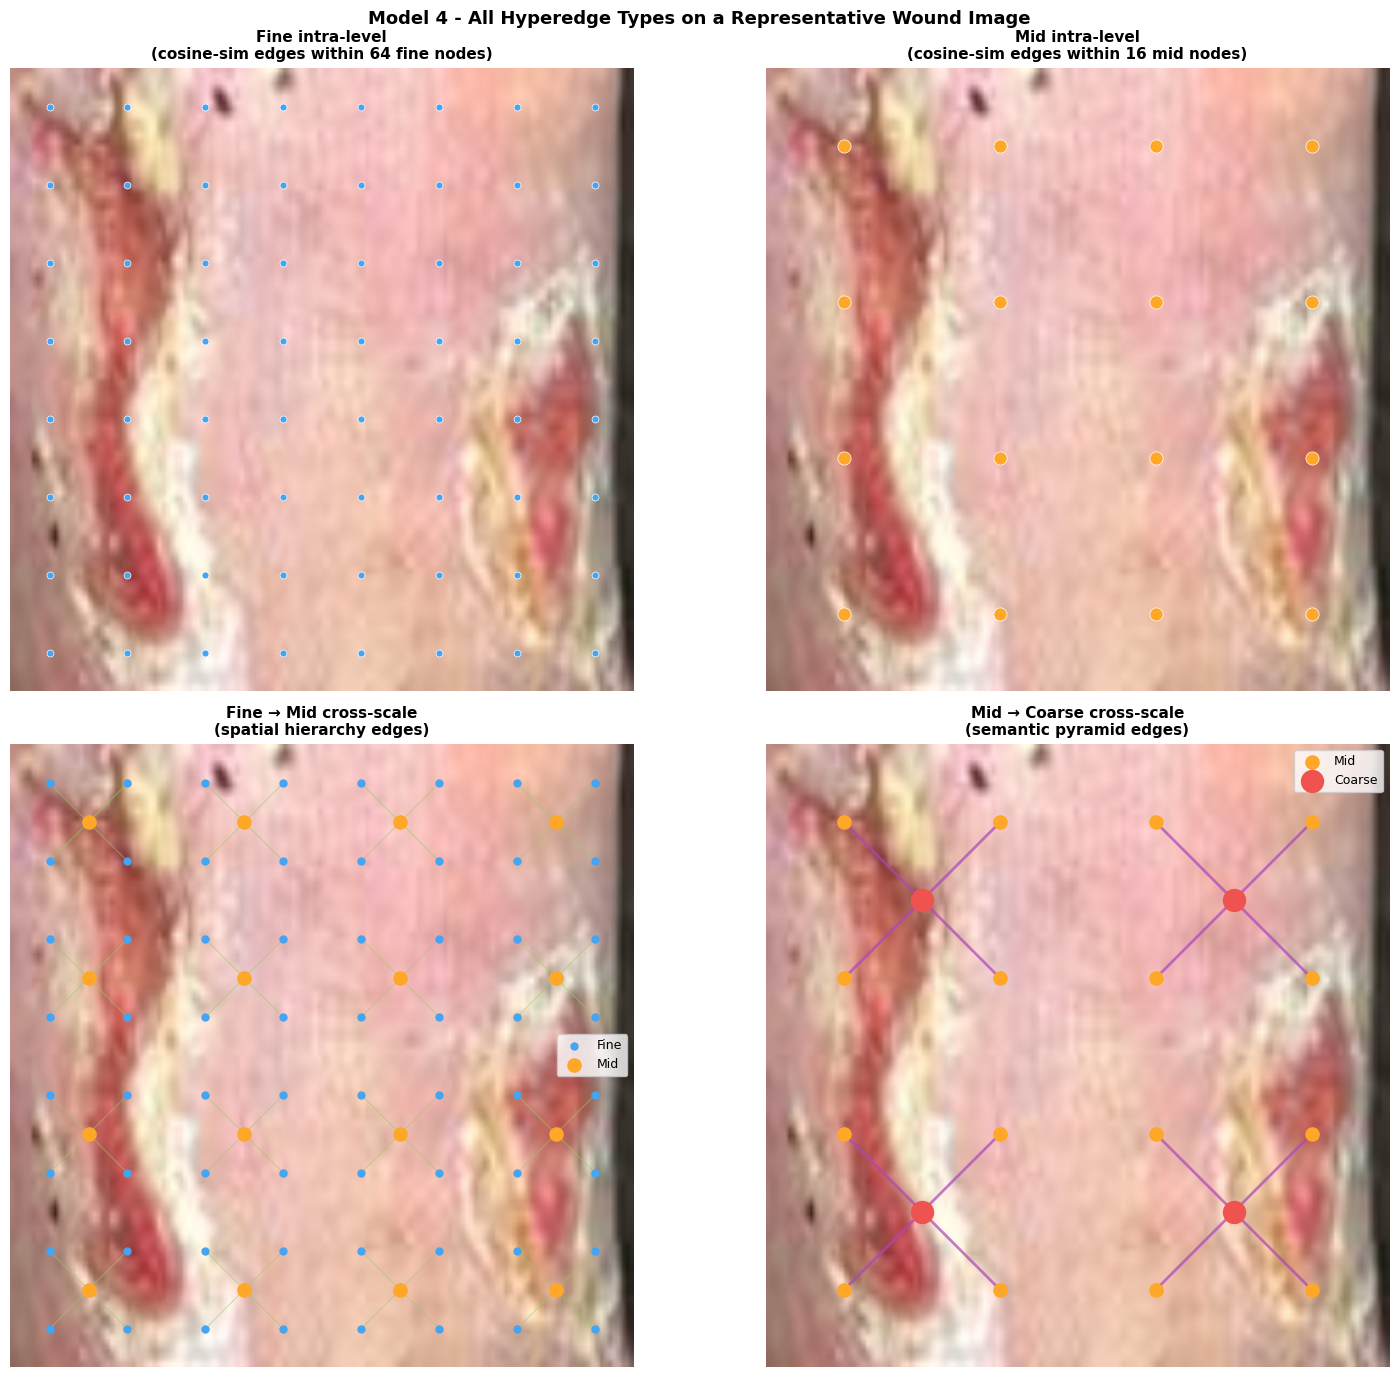

Saved hypergraph_all_edge_types_m4.png


In [22]:
# ── Figure (b): intra-level + cross-level edges, full 4-panel ────
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

panels = [
    ("Fine intra-level\n(cosine-sim edges within 64 fine nodes)", A_ff,
     fine_px_x, fine_px_y, "#42A5F5", 25),
    ("Mid intra-level\n(cosine-sim edges within 16 mid nodes)", A_mm,
     mid_px_x, mid_px_y, "#FFA726", 90),
    ("Fine → Mid cross-scale\n(spatial hierarchy edges)", None, None, None, None, None),
    ("Mid → Coarse cross-scale\n(semantic pyramid edges)", None, None, None, None, None),
]

# Panel 0 & 1: intra-level
for ax, (title, intra_adj, px_x, px_y, color, siz) in zip(axes[:2], panels[:2]):
    ax.imshow(img_np_viz)
    ii, jj = np.where(np.triu(intra_adj, k=1) > 0)
    rng2 = np.random.default_rng(SEED)
    if len(ii) > 400:
        sel = rng2.choice(len(ii), 400, replace=False); ii,jj = ii[sel],jj[sel]
    for a,b in zip(ii,jj):
        ax.plot([px_x[a],px_x[b]], [px_y[a],px_y[b]],
                color=color, lw=0.4, alpha=0.4, zorder=2)
    ax.scatter(px_x, px_y, c=color, s=siz, edgecolors="white", lw=0.5, zorder=3)
    ax.set_title(title, fontsize=11, fontweight="bold"); ax.axis("off")

# Panel 2: fine↔mid
axes[2].imshow(img_np_viz)
fi_idx, mi_idx = np.where(A_fm > 0)
for fi, mi in zip(fi_idx, mi_idx):
    axes[2].plot([fine_px_x[fi], mid_px_x[mi]], [fine_px_y[fi], mid_px_y[mi]],
                 color="#9CCC65", lw=0.8, alpha=0.5, zorder=2)
axes[2].scatter(fine_px_x, fine_px_y, c="#42A5F5", s=25,  zorder=3, label="Fine")
axes[2].scatter(mid_px_x,  mid_px_y,  c="#FFA726", s=90,  zorder=3, label="Mid")
axes[2].set_title(panels[2][0], fontsize=11, fontweight="bold")
axes[2].legend(fontsize=9); axes[2].axis("off")

# Panel 3: mid↔coarse
axes[3].imshow(img_np_viz)
mi2, ci = np.where(A_mc > 0)
for mi, ci_ in zip(mi2, ci):
    axes[3].plot([mid_px_x[mi], coarse_px_x[ci_]], [mid_px_y[mi], coarse_px_y[ci_]],
                 color="#AB47BC", lw=2.0, alpha=0.7, zorder=2)
axes[3].scatter(mid_px_x,    mid_px_y,    c="#FFA726", s=90,  zorder=3, label="Mid")
axes[3].scatter(coarse_px_x, coarse_px_y, c="#EF5350", s=250, zorder=3, label="Coarse")
axes[3].set_title(panels[3][0], fontsize=11, fontweight="bold")
axes[3].legend(fontsize=9); axes[3].axis("off")

plt.suptitle("Model 4 - All Hyperedge Types on a Representative Wound Image",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("hypergraph_all_edge_types_m4.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved hypergraph_all_edge_types_m4.png")


### 20b. Multi-Granularity Hyperedge Schematic

Clean abstract diagram showing the three-level pyramid (fine/mid/coarse) and the two types of edges (intra-level cosine-similarity, cross-scale spatial hierarchy). This goes in the Methodology section.

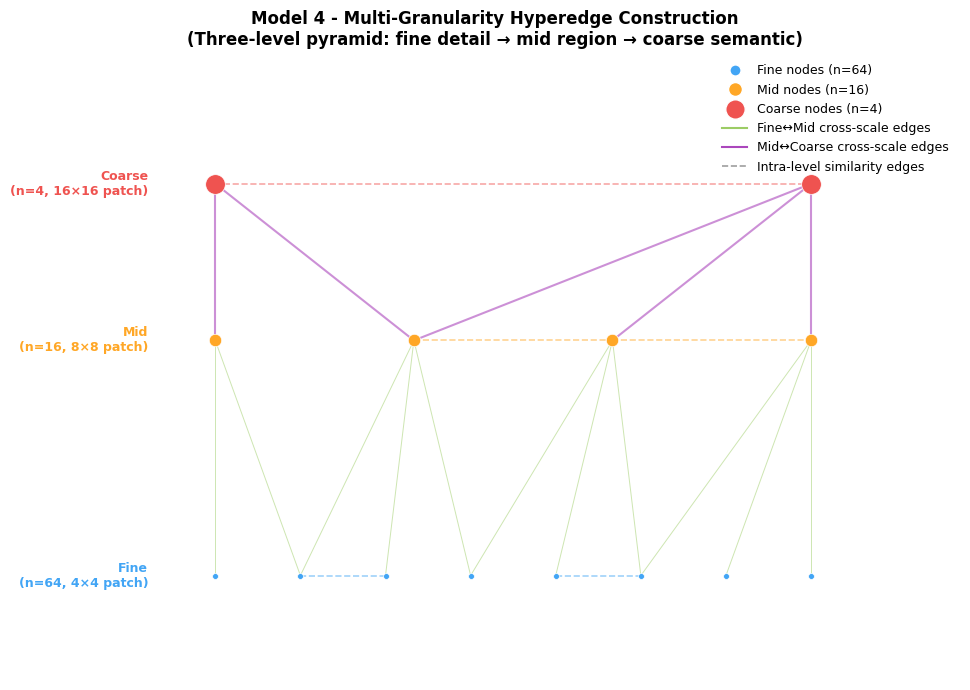

Saved hypergraph_schematic_m4.png


In [23]:
fig, ax = plt.subplots(figsize=(10, 7))

# Three rows: coarse (top) → mid → fine (bottom)
level_info = [
    ("Coarse\n(n=4, 16×16 patch)", 4,  2,  "#EF5350",  3.0, 200),
    ("Mid\n(n=16, 8×8 patch)",    16,  4,  "#FFA726",  1.8, 80),
    ("Fine\n(n=64, 4×4 patch)",   64,  8,  "#42A5F5",  0.0, 18),
]

node_positions = {}
for label, n, grid, color, y_base, siz in level_info:
    xs = np.linspace(1, 9, grid)
    for i, x in enumerate(xs):
        node_positions[(label, i)] = (x, y_base)
    ax.scatter(xs, [y_base]*len(xs), c=color, s=siz, zorder=4,
               edgecolors="white", linewidths=0.5)
    ax.text(0.1, y_base, label, va="center", ha="right", fontsize=9, fontweight="bold", color=color)

# Cross-scale edges: connect mid nodes to coarse nodes spatially
rng3 = np.random.default_rng(SEED)
mid_xs   = np.linspace(1,9,4)
coarse_xs = np.linspace(1,9,2)
fine_xs  = np.linspace(1,9,8)

for i, cx in enumerate(coarse_xs):
    for j, mx in enumerate(mid_xs):
        if abs(j - i*2) <= 1:
            ax.plot([mx, cx], [1.8, 3.0], color="#AB47BC", lw=1.5, alpha=0.6, zorder=2)

for i, mx in enumerate(mid_xs):
    targets = [j for j,fx in enumerate(fine_xs) if abs(j - i*2) <= 1]
    for t in targets:
        ax.plot([fine_xs[t], mx], [0.0, 1.8], color="#9CCC65", lw=0.7, alpha=0.5, zorder=2)

# Intra-level similarity edges (sample only)
for xs, y, color in [(fine_xs,0.0,"#42A5F5"),(mid_xs,1.8,"#FFA726"),(coarse_xs,3.0,"#EF5350")]:
    for i in range(len(xs)-1):
        if rng3.random() < 0.5:
            ax.plot([xs[i],xs[i+1]], [y,y], color=color, lw=1.2, alpha=0.5, zorder=2,
                    linestyle="dashed")

from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#42A5F5", markersize=8, label="Fine nodes (n=64)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#FFA726", markersize=10, label="Mid nodes (n=16)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#EF5350", markersize=14, label="Coarse nodes (n=4)"),
    Line2D([0],[0], color="#9CCC65", lw=1.5, label="Fine↔Mid cross-scale edges"),
    Line2D([0],[0], color="#AB47BC", lw=1.5, label="Mid↔Coarse cross-scale edges"),
    Line2D([0],[0], color="#9E9E9E", lw=1.2, linestyle="dashed", label="Intra-level similarity edges"),
]
ax.legend(handles=legend_elems, loc="upper right", fontsize=9, frameon=False)
ax.set_xlim(-1.5, 11); ax.set_ylim(-0.8, 4.0)
ax.set_title("Model 4 - Multi-Granularity Hyperedge Construction\n"
             "(Three-level pyramid: fine detail → mid region → coarse semantic)",
             fontsize=12, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("hypergraph_schematic_m4.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved hypergraph_schematic_m4.png")
